In [1]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole  # If using Jupyter Notebook

def analyze_fingerprint_bit(mol, bit_index, fingerprint_size=2048, radius=2):
    """
    Analyzes a specific bit in a Morgan fingerprint to identify the corresponding substructures.

    Args:
        mol: RDKit Mol object.
        bit_index: The index of the bit to analyze (e.g., 1308).
        fingerprint_size: The size of the folded fingerprint (default: 2048).
        radius: The radius used for Morgan fingerprint generation (default: 2).

    Returns:
        A list of tuples: [(atom_index, radius, substructure_image), ...].
        Each tuple represents a substructure that contributes to the specified bit.
        Returns an empty list if the molecule is None.
    """

    if mol is None:
        print("Warning: Input molecule is None. Returning empty list.")
        return []

    info = {}
    fp = AllChem.GetMorganFingerprint(mol, radius=radius, bitInfo=info)

    substructures = []
    for key, atom_radii in info.items():
        if key % fingerprint_size == bit_index:
            for atom_index, atom_radius in atom_radii:
                env = Chem.FindAtomEnvironmentOfRadiusN(mol, atom_radius, atom_index)
                amap = {}
                submol = Chem.PathToSubmol(mol, env, atomMap=amap)
                # Ensure the substructure is valid
                if submol is not None:
                   substructure_image = Draw.MolToImage(submol, size=(200, 200))  # Generate image
                   substructures.append((atom_index, atom_radius, substructure_image))  # Store image
                else:
                   print(f"Warning: Could not generate submol for atom {atom_index}, radius {atom_radius}, key {key}. Skipping.")

    return substructures


def visualize_substructures(substructures):
    """
    Visualizes the substructures returned by analyze_fingerprint_bit.

    Args:
        substructures: A list of tuples returned by analyze_fingerprint_bit.
    """
    if not substructures:
        print("No substructures to visualize.")
        return

    for atom_index, radius, substructure_image in substructures:
        print(f"Substructure around atom {atom_index} with radius {radius}:")
        display(substructure_image) # Use display() if in a Jupyter Notebook

# Example Usage (replace with your molecule and bit index):
# Assuming you have a list of SMILES strings called 'smiles_list' and have already
# created a Pandas DataFrame called 'counts_df' as in your original code.
#  Also, I'm adding error handling in the loop and a check to skip processing if the value is 0.
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw
from IPython.display import display #Required for displaying images in Jupyter Notebook
# Sample data (replace with your actual data)
smiles_list = ['O=C(C(C)=O)/C=C/C1=CC=CO1', 'O=C(/C=C/C1=CC=CC=C1)/C=C/C2=CC=CC=C2']  # Example SMILES
#Create a Pandas DataFrame containing Morgan Fingerprint
def generate_morgan_fingerprints(smiles_list, radius=2, nBits=2048):
    mol_objs = [Chem.MolFromSmiles(s) for s in smiles_list]
    fingerprints_counts = []
    for mol in mol_objs:
        if mol is not None:
            fp = AllChem.GetMorganFingerprint(mol, radius=radius, useCounts=True)
            count_dict = fp.GetNonzeroElements()
            count_array = np.zeros(nBits)
            for key, val in count_dict.items():
                count_array[key % nBits] = val
            fingerprints_counts.append(count_array)
        else:
            fingerprints_counts.append(np.nan * np.zeros(nBits))

    counts_df = pd.DataFrame(fingerprints_counts, columns=[f'C_FP_{i}' for i in range(nBits)])
    return counts_df, mol_objs

counts_df, mol_objs = generate_morgan_fingerprints(smiles_list)

# Specify the bit index you want to analyze
bit_index_to_analyze = 1667

# Iterate through molecules, skipping if the bit is zero and handling potential errors.
for i in range(len(smiles_list)):
    smiles = smiles_list[i]
    mol = mol_objs[i]  # Use the pre-calculated Mol object
    bit_value = counts_df.loc[i, f'C_FP_{bit_index_to_analyze}']

    if pd.isna(bit_value) or bit_value == 0:
        print(f"Skipping molecule {smiles} (index {i}) because bit {bit_index_to_analyze} is zero or NaN.")
        continue

    print(f"Analyzing molecule {smiles} (index {i}) for bit {bit_index_to_analyze}:")
    try:
        substructures = analyze_fingerprint_bit(mol, bit_index_to_analyze)
        visualize_substructures(substructures)
    except Exception as e:
        print(f"Error analyzing molecule {smiles} (index {i}): {e}")

print("Analysis complete.")



Skipping molecule O=C(C(C)=O)/C=C/C1=CC=CO1 (index 0) because bit 1667 is zero or NaN.
Skipping molecule O=C(/C=C/C1=CC=CC=C1)/C=C/C2=CC=CC=C2 (index 1) because bit 1667 is zero or NaN.
Analysis complete.


In [2]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole  # If using Jupyter Notebook
import pandas as pd
import numpy as np
from IPython.display import display #Required for displaying images in Jupyter Notebook

def analyze_fingerprint_bit(mol, bit_index, fingerprint_size=2048, fingerprint_radius=2, depiction_radius=3):
    """
    Analyzes a specific bit in a Morgan fingerprint to identify the corresponding substructures.

    Args:
        mol: RDKit Mol object.
        bit_index: The index of the bit to analyze (e.g., 1308).
        fingerprint_size: The size of the folded fingerprint (default: 2048).
        fingerprint_radius: The radius used for Morgan fingerprint generation (default: 2).
        depiction_radius: The radius used for substructure depiction (default: 3).

    Returns:
        A list of tuples: [(atom_index, radius, substructure_image), ...].
        Each tuple represents a substructure that contributes to the specified bit.
        Returns an empty list if the molecule is None.
    """

    if mol is None:
        print("Warning: Input molecule is None. Returning empty list.")
        return []

    info = {}
    fp = AllChem.GetMorganFingerprint(mol, radius=fingerprint_radius, bitInfo=info)

    substructures = []
    for key, atom_radii in info.items():
        if key % fingerprint_size == bit_index:
            for atom_index, atom_radius in atom_radii:
                env = Chem.FindAtomEnvironmentOfRadiusN(mol, depiction_radius, atom_index)
                amap = {}
                submol = Chem.PathToSubmol(mol, env, atomMap=amap)
                # Ensure the substructure is valid
                if submol is not None:
                   substructure_image = Draw.MolToImage(submol, size=(200, 200))  # Generate image
                   substructures.append((atom_index, depiction_radius, substructure_image))  # Store image
                else:
                   print(f"Warning: Could not generate submol for atom {atom_index}, radius {depiction_radius}, key {key}. Skipping.")

    return substructures


def visualize_substructures(substructures):
    """
    Visualizes the substructures returned by analyze_fingerprint_bit.

    Args:
        substructures: A list of tuples returned by analyze_fingerprint_bit.
    """
    if not substructures:
        print("No substructures to visualize.")
        return

    for atom_index, radius, substructure_image in substructures:
        print(f"Substructure around atom {atom_index} with radius {radius}:")
        display(substructure_image) # Use display() if in a Jupyter Notebook


# Sample data (replace with your actual data)
smiles_list = ['O=C(C(C)=O)/C=C/C1=CC=CO1', 'O=C(/C=C/C1=CC=CC=C1)/C=C/C2=CC=CC=C2']  # Example SMILES

#Create a Pandas DataFrame containing Morgan Fingerprint
def generate_morgan_fingerprints(smiles_list, radius=2, nBits=2048):
    mol_objs = [Chem.MolFromSmiles(s) for s in smiles_list]
    fingerprints_counts = []
    for mol in mol_objs:
        if mol is not None:
            fp = AllChem.GetMorganFingerprint(mol, radius=radius, useCounts=True)
            count_dict = fp.GetNonzeroElements()
            count_array = np.zeros(nBits)
            for key, val in count_dict.items():
                count_array[key % nBits] = val
            fingerprints_counts.append(count_array)
        else:
            fingerprints_counts.append(np.nan * np.zeros(nBits))

    counts_df = pd.DataFrame(fingerprints_counts, columns=[f'C_FP_{i}' for i in range(nBits)])
    return counts_df, mol_objs

counts_df, mol_objs = generate_morgan_fingerprints(smiles_list)

# Specify the bit index you want to analyze
bit_index_to_analyze = 1667

# Iterate through molecules, skipping if the bit is zero and handling potential errors.
for i in range(len(smiles_list)):
    smiles = smiles_list[i]
    mol = mol_objs[i]  # Use the pre-calculated Mol object
    bit_value = counts_df.loc[i, f'C_FP_{bit_index_to_analyze}']

    if pd.isna(bit_value) or bit_value == 0:
        print(f"Skipping molecule {smiles} (index {i}) because bit {bit_index_to_analyze} is zero or NaN.")
        continue

    print(f"Analyzing molecule {smiles} (index {i}) for bit {bit_index_to_analyze}:")
    try:
        substructures = analyze_fingerprint_bit(mol, bit_index_to_analyze, fingerprint_radius=2, depiction_radius=4)
        visualize_substructures(substructures)
    except Exception as e:
        print(f"Error analyzing molecule {smiles} (index {i}): {e}")

print("Analysis complete.")


Skipping molecule O=C(C(C)=O)/C=C/C1=CC=CO1 (index 0) because bit 1667 is zero or NaN.
Skipping molecule O=C(/C=C/C1=CC=CC=C1)/C=C/C2=CC=CC=C2 (index 1) because bit 1667 is zero or NaN.
Analysis complete.


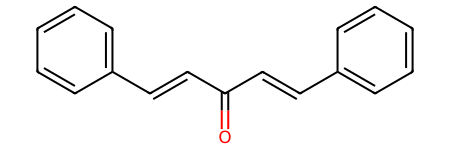

In [3]:
Chem.MolFromSmiles("O=C(/C=C/C1=CC=CC=C1)/C=C/C2=CC=CC=C2")

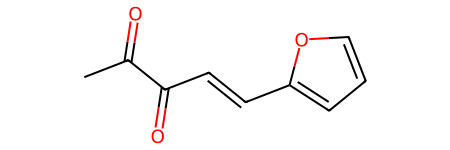

In [4]:
Chem.MolFromSmiles("O=C(C(C)=O)/C=C/C1=CC=CO1")

In [5]:
import sys
from pathlib import Path
prediction_mode_path = Path("../module")
sys.path.append(prediction_mode_path.as_posix())
import models_creation_cla as pred_model

import pandas as pd
import numpy as np

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from sklearn.model_selection import train_test_split
import math

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
#from sklearn import tree

from matplotlib import pyplot as plt

import joblib

from mordred import Calculator, descriptors
import mordred
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.Chem import Draw

import warnings
warnings.filterwarnings('ignore')

In [6]:
molecular_descriptors_df = pred_model.prepare_data('../Data/QSPR_epoxidation_classifier.xlsx')

100%|██████████████████████████████████████████████████████████████████████████████████| 67/67 [00:01<00:00, 37.27it/s]


Data size (rows, columns): (67, 3874)
Data size after first reduction (rows, columns): (67, 3329)
Data size after second reduction (rows, columns): (67, 1428)


In [7]:
target = 'epox_cla'
data = molecular_descriptors_df
#data[target] = load_prepared_data['ee']
data.head()

,AATS0Z,AATS0are,AATS0d,AATS0dv,AATS0i,AATS0m,AATS0p,AATS0pe,AATS0s,AATS0se,...,C_FP_1991,C_FP_1992,C_FP_1996,C_FP_1999,C_FP_2023,C_FP_2029,C_FP_2033,C_FP_2037,C_FP_2041,epox_cla
0,21.096774,5.806774,3.096774,6.451613,154.935746,83.174801,1.660974,5.923665,3.939068,7.356725,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1
1,32.285714,5.973175,3.321429,7.128748,153.200722,131.707465,1.861423,6.164168,4.175784,7.587078,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,32.285714,5.973175,3.321429,7.128748,153.200722,131.707465,1.861423,6.164168,4.175784,7.587078,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1
3,22.000000,5.860000,3.142857,6.857143,153.799230,86.861521,1.707574,5.980396,4.190476,7.395751,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1
4,21.562500,5.820625,3.375000,6.687500,154.056327,85.083842,1.696221,5.941753,3.793403,7.362468,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1


In [8]:
data[['C2SP2', 'C_FP_1308', 'C_FP_1667', 'C_FP_1750']]

,C2SP2,C_FP_1308,C_FP_1667,C_FP_1750
0,12,1.0,1.0,6.0
1,13,0.0,1.0,4.0
2,13,1.0,1.0,6.0
3,13,1.0,1.0,4.0
4,11,0.0,0.0,4.0
...,...,...,...,...
62,8,1.0,0.0,2.0
63,7,1.0,0.0,4.0
64,7,1.0,0.0,4.0
65,10,1.0,1.0,3.0


In [9]:
df_ = pd.read_excel('../Data/QSPR_epoxidation_classifier.xlsx')

Analyzing molecule CC1=CC=C(C=CC(=O)C2=CC=CC=C2)C=C1 (index 0) for bit 1667:
Substructure around atom 7 with radius 3:


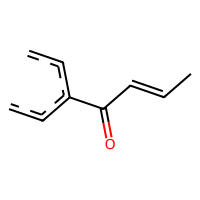

Analyzing molecule ClC1=CC=CC=C1C=CC(C2=CC=CC=C2)=O (index 1) for bit 1667:
Substructure around atom 9 with radius 3:


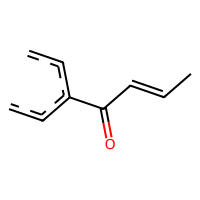

Analyzing molecule ClC1=CC=C(C=CC(=O)C2=CC=CC=C2)C=C1 (index 2) for bit 1667:
Substructure around atom 7 with radius 3:


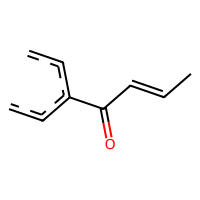

Analyzing molecule O=C(\C=C\C1=CC=CC=C1)C1=CC=CC=C1 (index 3) for bit 1667:
Substructure around atom 1 with radius 3:


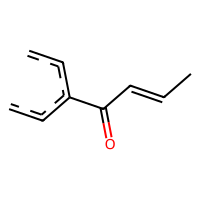

Skipping molecule O=C1C(CCC2=C1C=CC=C2)=CC3=CC=CC=C3 (index 4) because bit 1667 is zero or NaN.
Analyzing molecule O=C(C1=CC=CC=C1)C=CC2=CC=C(N(=O)=O)C=C2 (index 5) for bit 1667:
Substructure around atom 1 with radius 3:


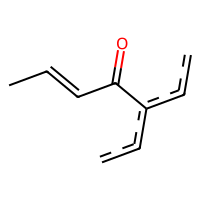

Analyzing molecule O=C(C1=CC=CC=C1)C=CC2=CC=CC(N(=O)=O)=C2 (index 6) for bit 1667:
Substructure around atom 1 with radius 3:


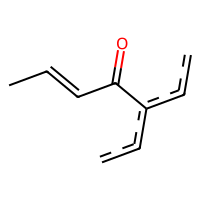

Analyzing molecule O=C(C1=CC=CC=C1)C=CC2=CC=CC=C2N(=O)=O (index 7) for bit 1667:
Substructure around atom 1 with radius 3:


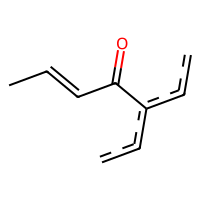

Analyzing molecule BrC1=CC=C(C=CC(=O)C2=CC=CC=C2)C=C1 (index 8) for bit 1667:
Substructure around atom 7 with radius 3:


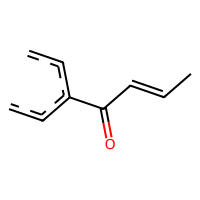

Skipping molecule CC1=CC(CCC1)=O (index 9) because bit 1667 is zero or NaN.
Analyzing molecule CC1=CC=C(C=C1)C(=O)C=CC1=CC=CC=C1 (index 10) for bit 1667:
Substructure around atom 7 with radius 3:


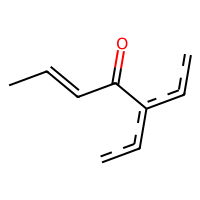

Skipping molecule O=C1CCCCC=C1 (index 11) because bit 1667 is zero or NaN.
Analyzing molecule O=C(C=CC1=CC2=CC=CC=C2C=C1)C1=CC=CC=C1 (index 12) for bit 1667:
Substructure around atom 1 with radius 3:


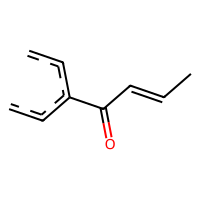

Analyzing molecule O=C(C1=CC=CC=C1)C=CC2=C3C=CC=CC3=CC=C2 (index 13) for bit 1667:
Substructure around atom 1 with radius 3:


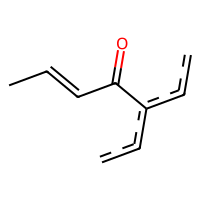

Analyzing molecule FC1=CC=C(C=C1)C(=O)C=CC1=CC=CC=C1 (index 14) for bit 1667:
Substructure around atom 7 with radius 3:


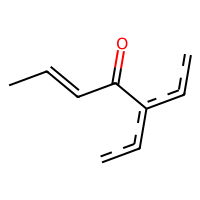

Skipping molecule O=C1/C(C(C2=CC=CC=C12)=O)=C\C3=CC=CC=C3 (index 15) because bit 1667 is zero or NaN.
Analyzing molecule O=C(C=CC1=CC=CC=C1)C1=CC=CO1 (index 16) for bit 1667:
Substructure around atom 1 with radius 3:


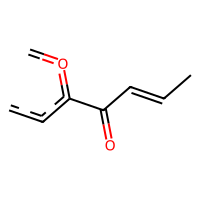

Skipping molecule CC(C)C(=O)C=CC1=CC=CC=C1 (index 17) because bit 1667 is zero or NaN.
Analyzing molecule O=C(C=CC1=CC2=CC=CC=C2S1)C1=CC=CC=C1 (index 18) for bit 1667:
Substructure around atom 1 with radius 3:


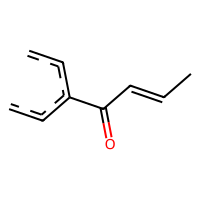

Analyzing molecule O=C(C=CC1=CC=CC=C1)C1=CC=CS1 (index 19) for bit 1667:
Substructure around atom 1 with radius 3:


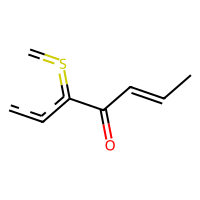

Analyzing molecule O=C(C=CC1=CC=CC=C1)C1=CC2=C(O1)C=CC=C2 (index 20) for bit 1667:
Substructure around atom 1 with radius 3:


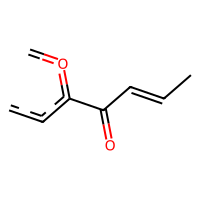

Analyzing molecule O=C(C=CC1=CC=CC=C1)C1=CC2=C(S1)C=CC=C2 (index 21) for bit 1667:
Substructure around atom 1 with radius 3:


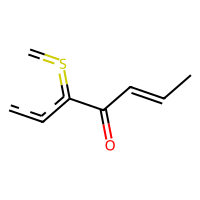

Analyzing molecule O=C(C=CC1=CC=C(C=C1)C#N)C1=CC=CC=C1 (index 22) for bit 1667:
Substructure around atom 1 with radius 3:


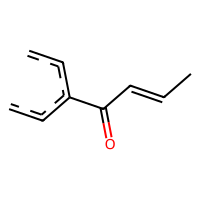

Analyzing molecule O=C(C=CC1=CC=CC=C1)C1=CC2=C(C=CC=C2)C=C1 (index 23) for bit 1667:
Substructure around atom 1 with radius 3:


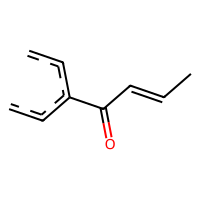

Analyzing molecule FC1=CC=C(C=C1)C(=O)C=CC1=CC=C(Cl)C=C1 (index 24) for bit 1667:
Substructure around atom 7 with radius 3:


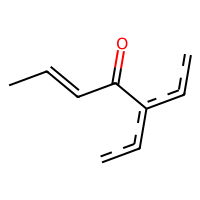

Analyzing molecule O=C(\C=C\C=C\C1=CC=CC=C1)C1=CC=CC=C1 (index 25) for bit 1667:
Substructure around atom 1 with radius 3:


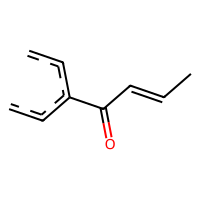

Analyzing molecule C\C=C\C=C\C(=O)C1=CC=CC=C1 (index 26) for bit 1667:
Substructure around atom 5 with radius 3:


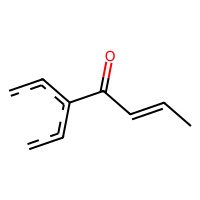

Analyzing molecule CC1=CC=CC=C1C(=O)C=CC1=CC=CC=C1 (index 27) for bit 1667:
Substructure around atom 7 with radius 3:


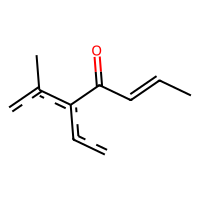

Analyzing molecule FC(F)(C1=CC=C(C=C1)C=CC(C2=CC=CC=C2)=O)F (index 28) for bit 1667:
Substructure around atom 11 with radius 3:


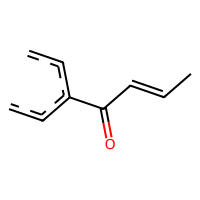

Analyzing molecule FC1=CC=C(C=CC(=O)C2=CC=C(C=C2)N(=O)=O)C=C1 (index 29) for bit 1667:
Substructure around atom 7 with radius 3:


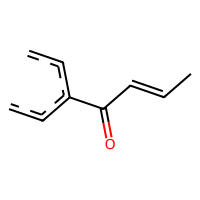

Analyzing molecule COC1=CC(C=CC(C2=CC=CC=C2)=O)=CC=C1 (index 30) for bit 1667:
Substructure around atom 7 with radius 3:


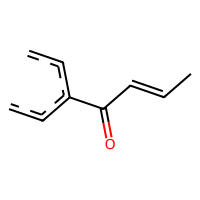

Analyzing molecule CN1C=CC=C1C(=O)C=CC1=CC=CC=C1 (index 31) for bit 1667:
Substructure around atom 6 with radius 3:


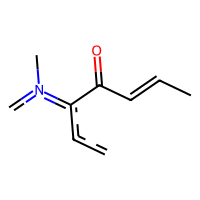

Analyzing molecule O=C(C1=CC=CC2=C1C=CC=C2)C=CC3=CC=CC=C3 (index 32) for bit 1667:
Substructure around atom 1 with radius 3:


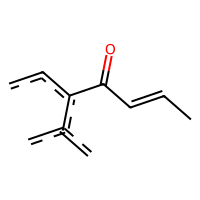

Analyzing molecule O=C(C1=CC=CC=C1)C=C2CCCC=C2 (index 33) for bit 1667:
Substructure around atom 1 with radius 3:


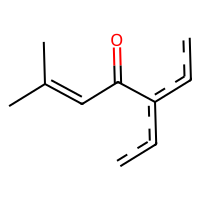

Analyzing molecule CC(C=CC(C1=CC=CC=C1)=O)C (index 34) for bit 1667:
Substructure around atom 4 with radius 3:


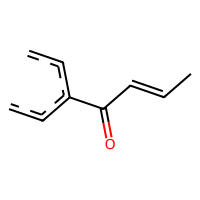

Analyzing molecule CC1=CC=C(C=C1)C=CC(C2=CC=C(N(=O)=O)C=C2)=O (index 35) for bit 1667:
Substructure around atom 9 with radius 3:


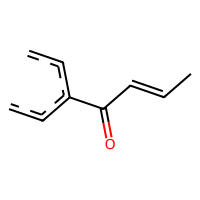

Analyzing molecule ClC1=CC=C(C=CC(C2=CC=C(C=C2)N(=O)=O)=O)C=C1 (index 36) for bit 1667:
Substructure around atom 7 with radius 3:


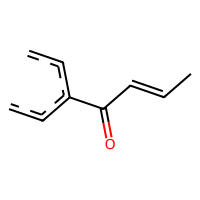

Analyzing molecule O=C(C1=CC=CC=C1)C=CC(C2=CC=CC=C2)=O (index 37) for bit 1667:
Substructure around atom 1 with radius 3:


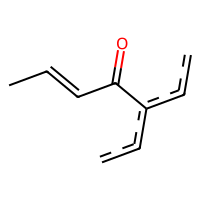

Substructure around atom 10 with radius 3:


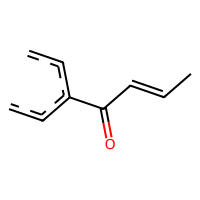

Skipping molecule CCCCCC=CC(C)=O (index 38) because bit 1667 is zero or NaN.
Skipping molecule O=C1C(C)=CCCC1 (index 39) because bit 1667 is zero or NaN.
Analyzing molecule O=C(/C=C/C1=CC=CC=C1C)C2=CC=CC=C2 (index 40) for bit 1667:
Substructure around atom 1 with radius 3:


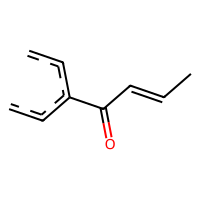

Analyzing molecule O=C(/C=C/C1=CC=CC=C1OC)C2=CC=CC=C2 (index 41) for bit 1667:
Substructure around atom 1 with radius 3:


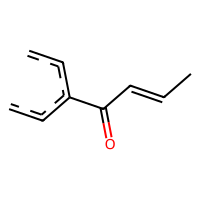

Analyzing molecule O=C(/C=C/C1=CC=C(OC)C=C1)C2=CC=CC=C2 (index 42) for bit 1667:
Substructure around atom 1 with radius 3:


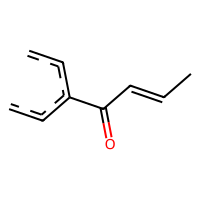

Analyzing molecule O=C(/C=C/C1=CC=CO1)C2=CC=CC=C2 (index 43) for bit 1667:
Substructure around atom 1 with radius 3:


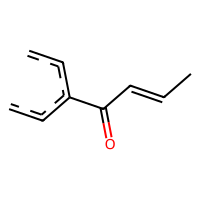

Analyzing molecule O=C(/C=C/C1=CC=CN1)C2=CC=CC=C2 (index 44) for bit 1667:
Substructure around atom 1 with radius 3:


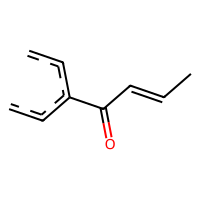

Analyzing molecule O=C(/C=C/C1=CC=CS1)C2=CC=CC=C2 (index 45) for bit 1667:
Substructure around atom 1 with radius 3:


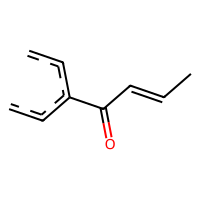

Analyzing molecule O=C(/C=C1CCCCCC/1)C2=CC=CC=C2 (index 46) for bit 1667:
Substructure around atom 1 with radius 3:


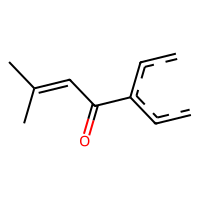

Skipping molecule CCCCCCC(/C=C/C1=CC=CC=C1)=O (index 47) because bit 1667 is zero or NaN.
Skipping molecule O=C1CCC(C2=CC=CC=C2)=C1 (index 48) because bit 1667 is zero or NaN.
Analyzing molecule CC1=CC=C(C(/C=C/C2=C(C)C=C(C)C=C2C)=O)C=C1 (index 49) for bit 1667:
Substructure around atom 5 with radius 3:


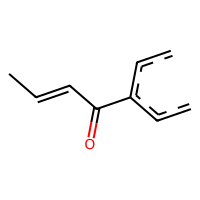

Analyzing molecule O=C(/C=C/C1=C(C)C=C(C)C=C1C)C2=CC=C([N+]([O-])=O)C=C2 (index 50) for bit 1667:
Substructure around atom 1 with radius 3:


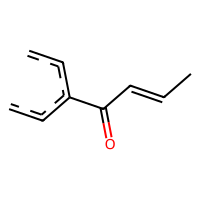

Skipping molecule O=C(CCCC/1=O)C1=C\C2=CC=CC=C2 (index 51) because bit 1667 is zero or NaN.
Skipping molecule O=C(C=CC/1=O)C1=C/C2=CC=CC=C2 (index 52) because bit 1667 is zero or NaN.
Skipping molecule O=S(/C=C/C1=CC=CC=C1)(C2=CC=CC=C2)=O (index 53) because bit 1667 is zero or NaN.
Skipping molecule O=[N+](/C=C/C1=CC=CC=C1)[O-] (index 54) because bit 1667 is zero or NaN.
Skipping molecule O=C(C1=CC=CC=C1)C/C=C/C2=CC=CC=C2 (index 55) because bit 1667 is zero or NaN.
Skipping molecule OC/C=C/C1=CC=CC=C1 (index 56) because bit 1667 is zero or NaN.
Analyzing molecule O=C(/C=C/C1=CC=C(OC2=CC=CC=C2)C=C1)C3=CC=CC=C3 (index 57) for bit 1667:
Substructure around atom 1 with radius 3:


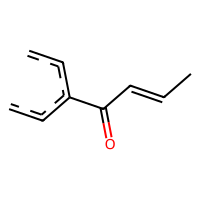

Analyzing molecule O=C(/C=C/C1=CC=C(CC(C)C)C=C1)C2=CC=CC=C2 (index 58) for bit 1667:
Substructure around atom 1 with radius 3:


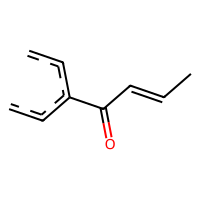

Analyzing molecule O=C(/C=C/C1=CC=C(C=C(OC)C=C2)C2=C1)C3=CC=CC=C3 (index 59) for bit 1667:
Substructure around atom 1 with radius 3:


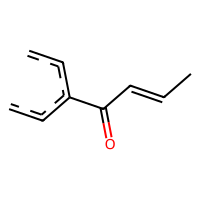

Skipping molecule O=C(/C=C/C1=CC=CC=C1)C(C)(C)C (index 60) because bit 1667 is zero or NaN.
Skipping molecule O=C(/C=C/C1=CC=C(OC)C=C1)C(C)(C)C (index 61) because bit 1667 is zero or NaN.
Skipping molecule O=C(/C=C/C1=CC=CC=C1)C2CCCCC2 (index 62) because bit 1667 is zero or NaN.
Skipping molecule O=C(/C=C/C1=CC=C(OC)C=C1)OCC (index 63) because bit 1667 is zero or NaN.
Skipping molecule O=C(/C=C/C1=CC=C(Br)C=C1)OCC (index 64) because bit 1667 is zero or NaN.
Analyzing molecule O=C(/C=C/C1=CC=CC=C1)C2=CC=CN=C2 (index 65) for bit 1667:
Substructure around atom 1 with radius 3:


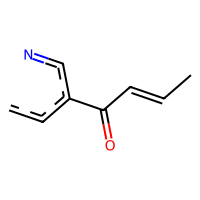

Skipping molecule CC(C1=CC[C@]2([H])[C@]1(C)CC[C@@]3([H])[C@@]2([H])CC=C4[C@]3(C)CC[C@H](OC(C)=O)C4)=O (index 66) because bit 1667 is zero or NaN.
Analysis complete.


In [10]:
counts_df, mol_objs = generate_morgan_fingerprints(df_['SMILES'])

# Specify the bit index you want to analyze
bit_index_to_analyze = 1667

# Iterate through molecules, skipping if the bit is zero and handling potential errors.
for i in range(len(df_['SMILES'])):
    smiles = df_['SMILES'][i]
    mol = mol_objs[i]  # Use the pre-calculated Mol object
    bit_value = counts_df.loc[i, f'C_FP_{bit_index_to_analyze}']

    if pd.isna(bit_value) or bit_value == 0:
        print(f"Skipping molecule {smiles} (index {i}) because bit {bit_index_to_analyze} is zero or NaN.")
        continue

    print(f"Analyzing molecule {smiles} (index {i}) for bit {bit_index_to_analyze}:")
    try:
        substructures = analyze_fingerprint_bit(mol, bit_index_to_analyze, fingerprint_radius=2, depiction_radius=3)
        visualize_substructures(substructures)
    except Exception as e:
        print(f"Error analyzing molecule {smiles} (index {i}): {e}")

print("Analysis complete.")

In [11]:
counts_df.head()

,C_FP_0,C_FP_1,C_FP_2,C_FP_3,C_FP_4,C_FP_5,C_FP_6,C_FP_7,C_FP_8,C_FP_9,...,C_FP_2038,C_FP_2039,C_FP_2040,C_FP_2041,C_FP_2042,C_FP_2043,C_FP_2044,C_FP_2045,C_FP_2046,C_FP_2047
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [12]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import display, SVG  # For inline SVG display
import pandas as pd
import numpy as np

def analyze_fingerprint_bit(mol, bit_index, fingerprint_size=2048, fingerprint_radius=2, depiction_radius=2):
    """
    Analyzes a specific bit in a Morgan fingerprint to identify the corresponding substructures.

    Returns:
        A list of tuples: [(atom_index, radius, submol), ...].
        Each tuple represents a substructure that contributes to the specified bit.
    """
    if mol is None:
        print("Warning: Input molecule is None. Returning empty list.")
        return []

    info = {}
    fp = AllChem.GetMorganFingerprint(mol, radius=fingerprint_radius, bitInfo=info)
    substructures = []

    for key, atom_radii in info.items():
        if key % fingerprint_size == bit_index:
            for atom_index, atom_radius in atom_radii:
                env = Chem.FindAtomEnvironmentOfRadiusN(mol, depiction_radius, atom_index)
                amap = {}
                submol = Chem.PathToSubmol(mol, env, atomMap=amap)
                if submol is not None:
                    substructures.append((atom_index, depiction_radius, submol))
                else:
                    print(f"Warning: Could not generate submol for atom {atom_index}, radius {depiction_radius}, key {key}. Skipping.")

    return substructures

def save_substructure_as_svg(submol, filename, size=(700, 700)):
    """
    Saves a substructure RDKit Mol object as an SVG file.
    """
    drawer = rdMolDraw2D.MolDraw2DSVG(size[0], size[1])
    drawer.DrawMolecule(submol)
    drawer.FinishDrawing()
    svg = drawer.GetDrawingText()
    with open(filename, 'w') as f:
        f.write(svg)

def generate_morgan_fingerprints(smiles_list, radius=2, nBits=2048):
    mol_objs = [Chem.MolFromSmiles(s) for s in smiles_list]
    fingerprints_counts = []

    for mol in mol_objs:
        if mol is not None:
            fp = AllChem.GetMorganFingerprint(mol, radius=radius, useCounts=True)
            count_dict = fp.GetNonzeroElements()
            count_array = np.zeros(nBits)
            for key, val in count_dict.items():
                count_array[key % nBits] = val
            fingerprints_counts.append(count_array)
        else:
            fingerprints_counts.append(np.nan * np.zeros(nBits))

    counts_df = pd.DataFrame(fingerprints_counts, columns=[f'C_FP_{i}' for i in range(nBits)])
    return counts_df, mol_objs

# Sample data (replace with your actual data)
smiles_list = ['O=C(C(C)=O)/C=C/C1=CC=CO1', 'O=C(/C=C/C1=CC=CC=C1)/C=C/C2=CC=CC=C2']

# Generate Morgan Fingerprints
counts_df, mol_objs = generate_morgan_fingerprints(smiles_list)

# Specify the bit index you want to analyze
bit_index_to_analyze = 1667

# Iterate through molecules, skipping if the bit is zero and handling potential errors.
for i in range(len(smiles_list)):
    smiles = smiles_list[i]
    mol = mol_objs[i]
    bit_value = counts_df.loc[i, f'C_FP_{bit_index_to_analyze}']

    if pd.isna(bit_value) or bit_value == 0:
        print(f"Skipping molecule {smiles} (index {i}) because bit {bit_index_to_analyze} is zero or NaN.")
        continue

    print(f"Analyzing molecule {smiles} (index {i}) for bit {bit_index_to_analyze}:")
    try:
        substructures = analyze_fingerprint_bit(mol, bit_index_to_analyze, fingerprint_radius=2, depiction_radius=2)
        if not substructures:
            print(f"No substructures found for molecule index {i}.")
            continue

        for idx, (atom_index, radius, submol) in enumerate(substructures):
            filename = f"substructure_molecule_{i}_idx_{idx}.svg"
            save_substructure_as_svg(submol, filename)
            print(f"Saved substructure SVG: {filename}")

            # Optional: display SVG inline (only in Jupyter Notebook or IPython environment)
            display(SVG(filename=filename))

    except Exception as e:
        print(f"Error analyzing molecule {smiles} (index {i}): {e}")

print("Analysis complete.")

Skipping molecule O=C(C(C)=O)/C=C/C1=CC=CO1 (index 0) because bit 1667 is zero or NaN.
Skipping molecule O=C(/C=C/C1=CC=CC=C1)/C=C/C2=CC=CC=C2 (index 1) because bit 1667 is zero or NaN.
Analysis complete.


Analyzing molecule CC1=CC=C(C=CC(=O)C2=CC=CC=C2)C=C1 (index 0) for bit 1667:
Saved substructure SVG: substructure_molecule_0_idx_0.svg


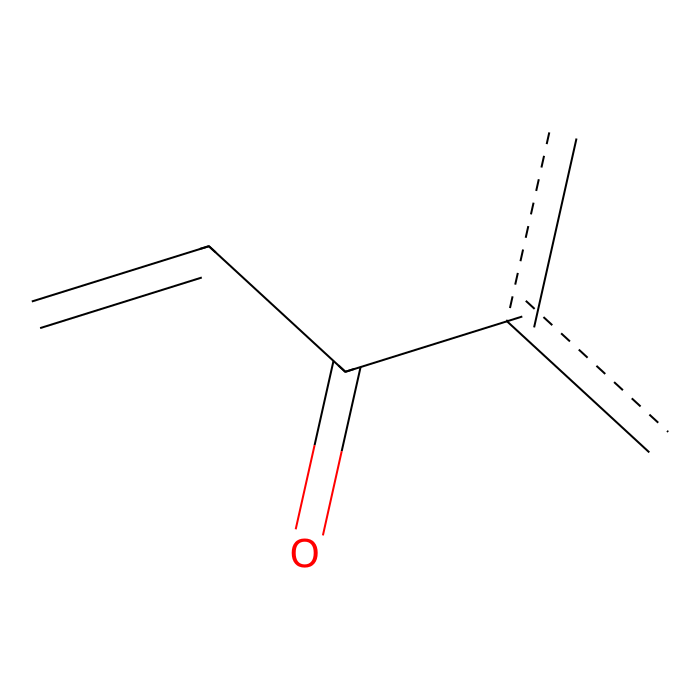

Analyzing molecule ClC1=CC=CC=C1C=CC(C2=CC=CC=C2)=O (index 1) for bit 1667:
Saved substructure SVG: substructure_molecule_1_idx_0.svg


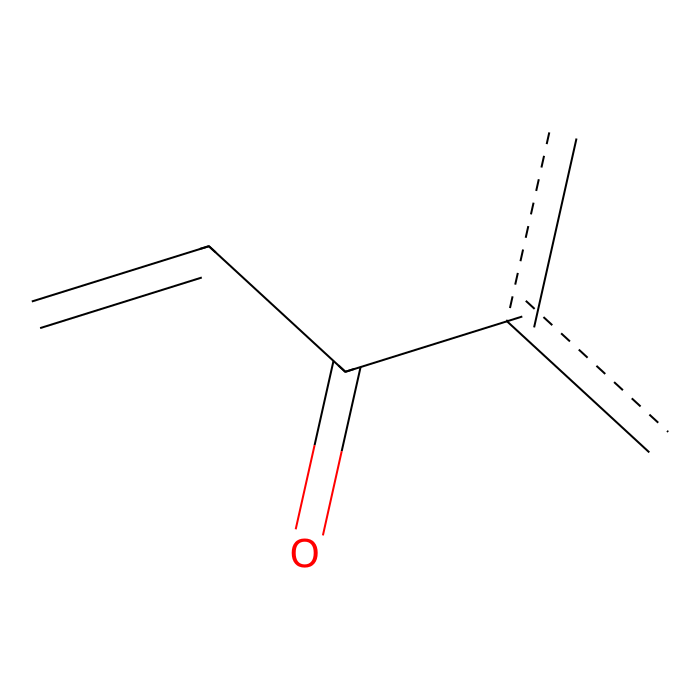

Analyzing molecule ClC1=CC=C(C=CC(=O)C2=CC=CC=C2)C=C1 (index 2) for bit 1667:
Saved substructure SVG: substructure_molecule_2_idx_0.svg


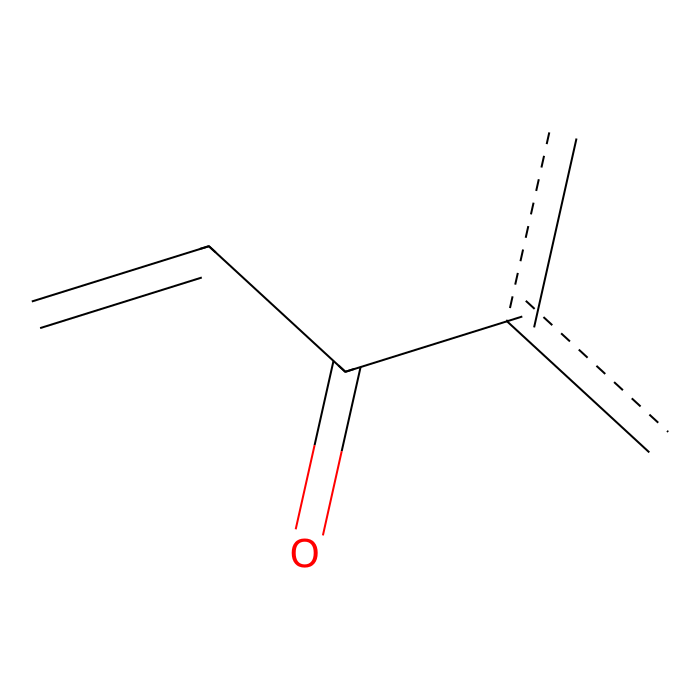

Analyzing molecule O=C(\C=C\C1=CC=CC=C1)C1=CC=CC=C1 (index 3) for bit 1667:
Saved substructure SVG: substructure_molecule_3_idx_0.svg


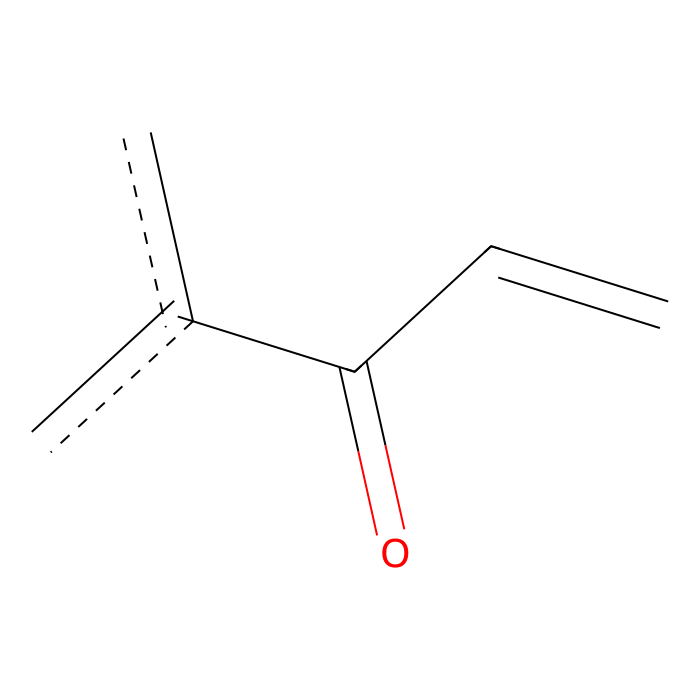

Skipping molecule O=C1C(CCC2=C1C=CC=C2)=CC3=CC=CC=C3 (index 4) because bit 1667 is zero or NaN.
Analyzing molecule O=C(C1=CC=CC=C1)C=CC2=CC=C(N(=O)=O)C=C2 (index 5) for bit 1667:
Saved substructure SVG: substructure_molecule_5_idx_0.svg


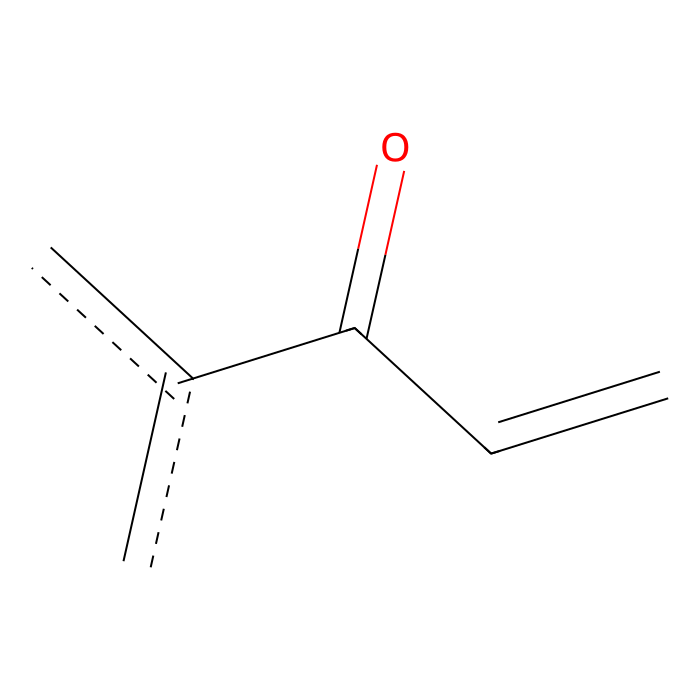

Analyzing molecule O=C(C1=CC=CC=C1)C=CC2=CC=CC(N(=O)=O)=C2 (index 6) for bit 1667:
Saved substructure SVG: substructure_molecule_6_idx_0.svg


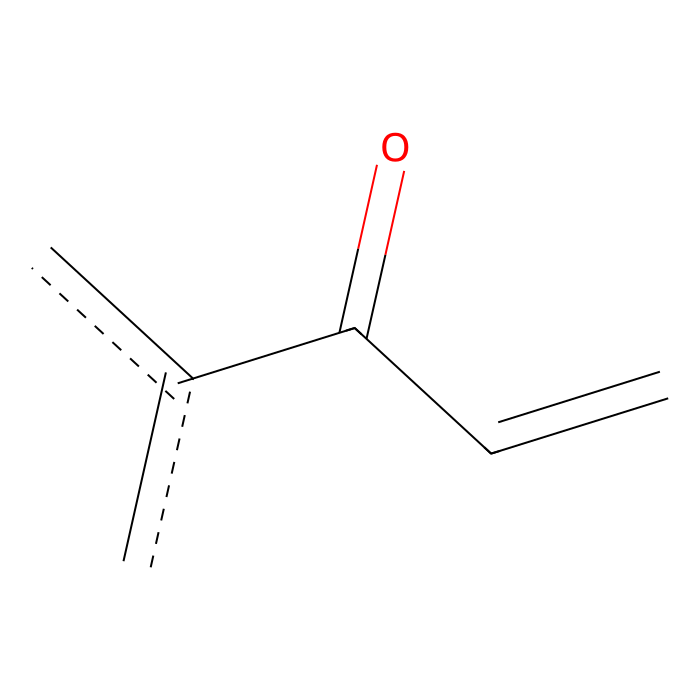

Analyzing molecule O=C(C1=CC=CC=C1)C=CC2=CC=CC=C2N(=O)=O (index 7) for bit 1667:
Saved substructure SVG: substructure_molecule_7_idx_0.svg


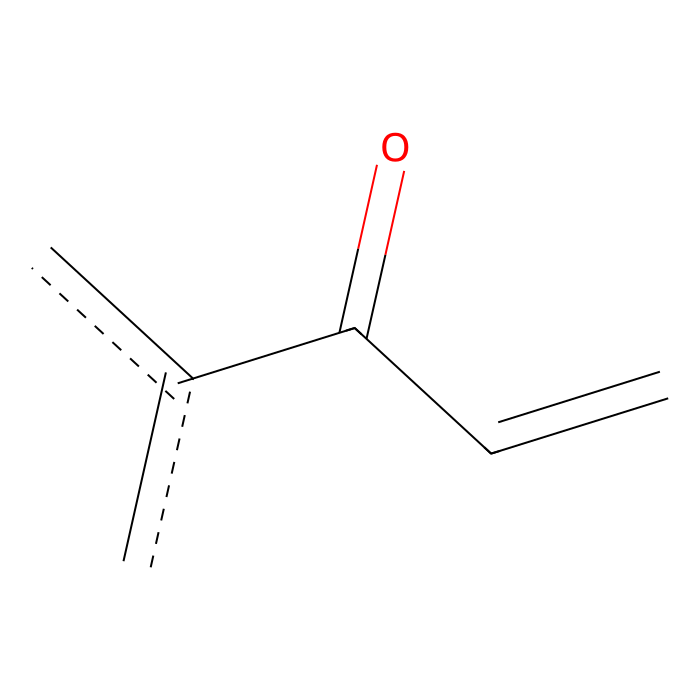

Analyzing molecule BrC1=CC=C(C=CC(=O)C2=CC=CC=C2)C=C1 (index 8) for bit 1667:
Saved substructure SVG: substructure_molecule_8_idx_0.svg


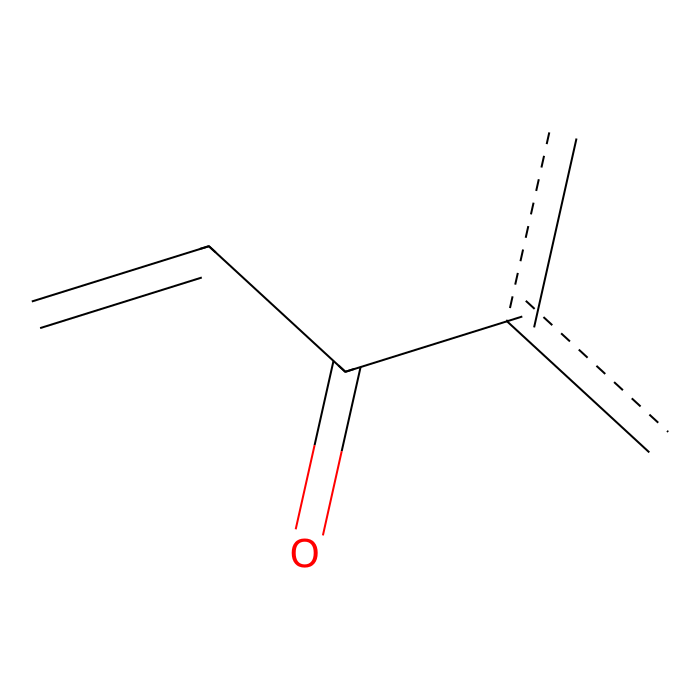

Skipping molecule CC1=CC(CCC1)=O (index 9) because bit 1667 is zero or NaN.
Analyzing molecule CC1=CC=C(C=C1)C(=O)C=CC1=CC=CC=C1 (index 10) for bit 1667:
Saved substructure SVG: substructure_molecule_10_idx_0.svg


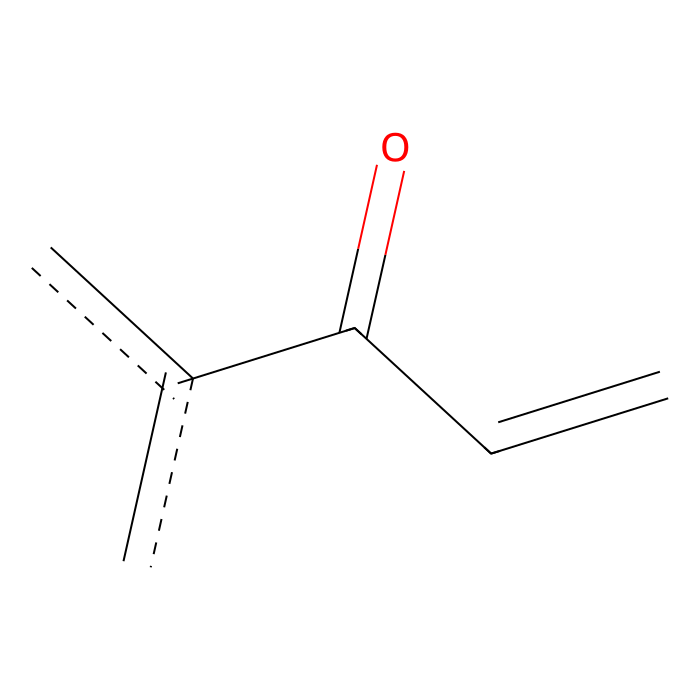

Skipping molecule O=C1CCCCC=C1 (index 11) because bit 1667 is zero or NaN.
Analyzing molecule O=C(C=CC1=CC2=CC=CC=C2C=C1)C1=CC=CC=C1 (index 12) for bit 1667:
Saved substructure SVG: substructure_molecule_12_idx_0.svg


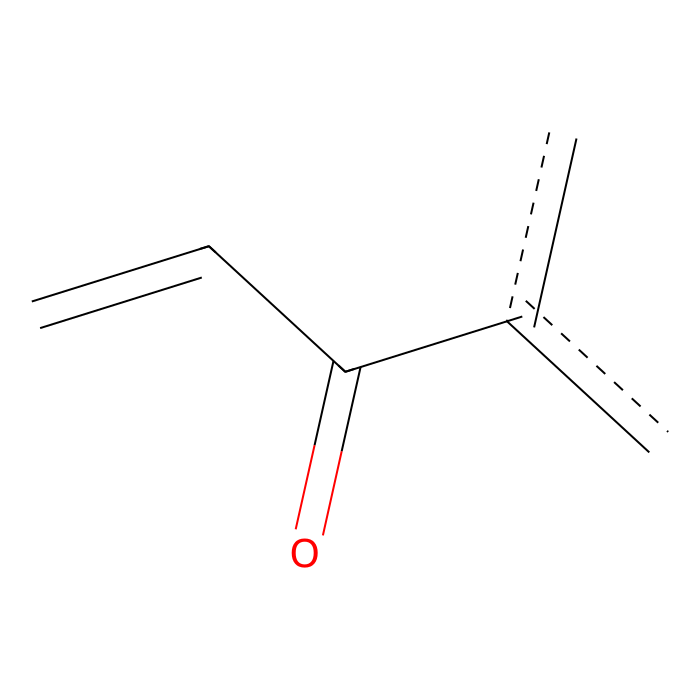

Analyzing molecule O=C(C1=CC=CC=C1)C=CC2=C3C=CC=CC3=CC=C2 (index 13) for bit 1667:
Saved substructure SVG: substructure_molecule_13_idx_0.svg


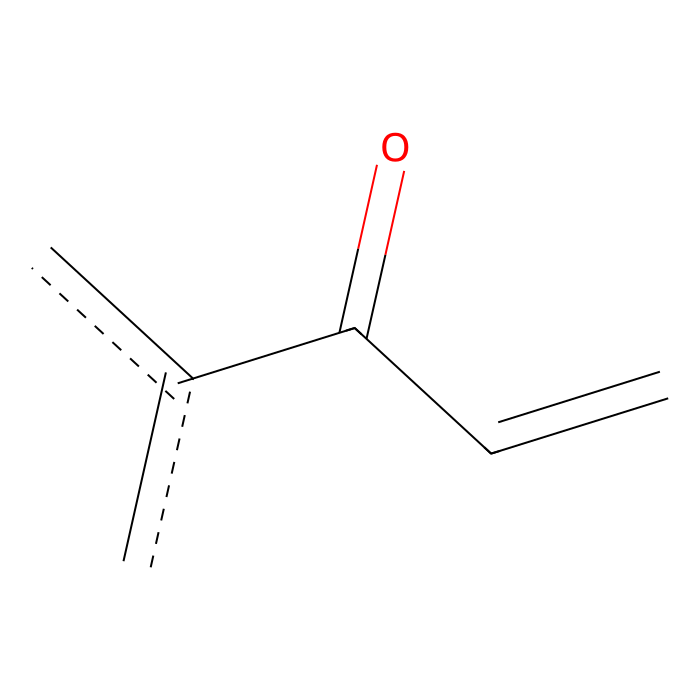

Analyzing molecule FC1=CC=C(C=C1)C(=O)C=CC1=CC=CC=C1 (index 14) for bit 1667:
Saved substructure SVG: substructure_molecule_14_idx_0.svg


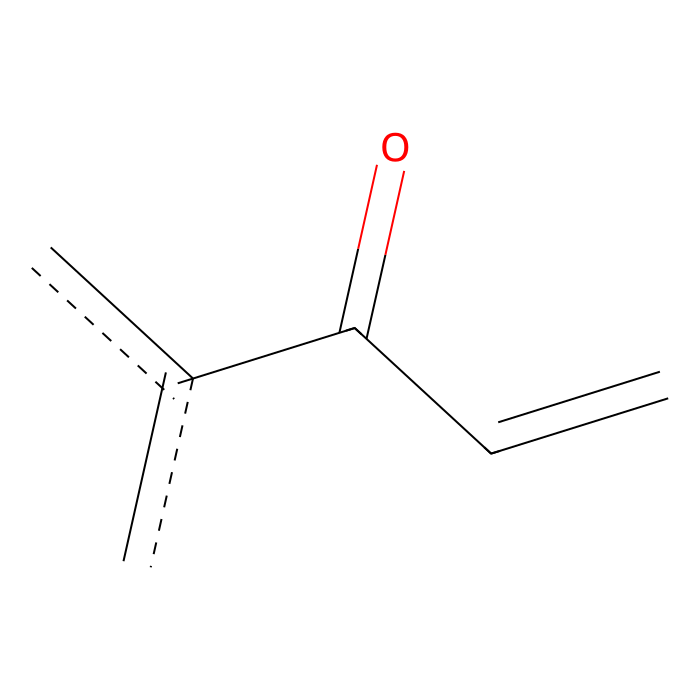

Skipping molecule O=C1/C(C(C2=CC=CC=C12)=O)=C\C3=CC=CC=C3 (index 15) because bit 1667 is zero or NaN.
Analyzing molecule O=C(C=CC1=CC=CC=C1)C1=CC=CO1 (index 16) for bit 1667:
Saved substructure SVG: substructure_molecule_16_idx_0.svg


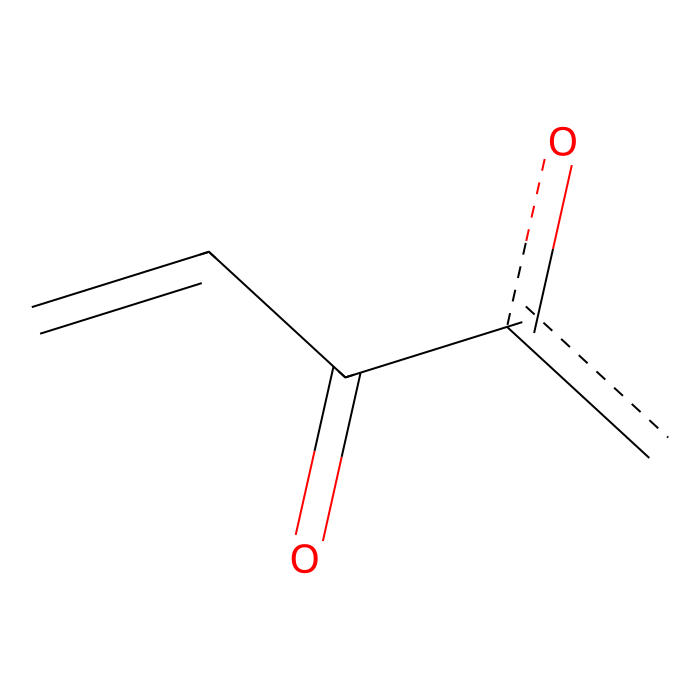

Skipping molecule CC(C)C(=O)C=CC1=CC=CC=C1 (index 17) because bit 1667 is zero or NaN.
Analyzing molecule O=C(C=CC1=CC2=CC=CC=C2S1)C1=CC=CC=C1 (index 18) for bit 1667:
Saved substructure SVG: substructure_molecule_18_idx_0.svg


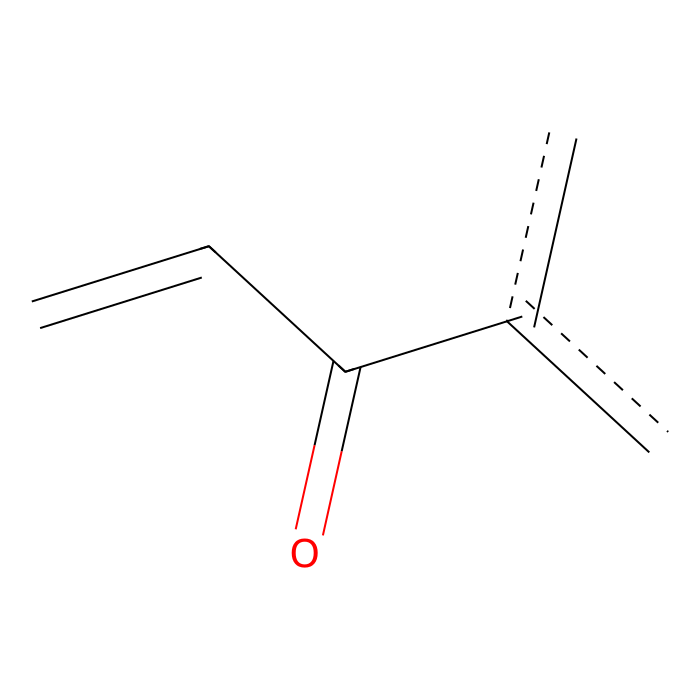

Analyzing molecule O=C(C=CC1=CC=CC=C1)C1=CC=CS1 (index 19) for bit 1667:
Saved substructure SVG: substructure_molecule_19_idx_0.svg


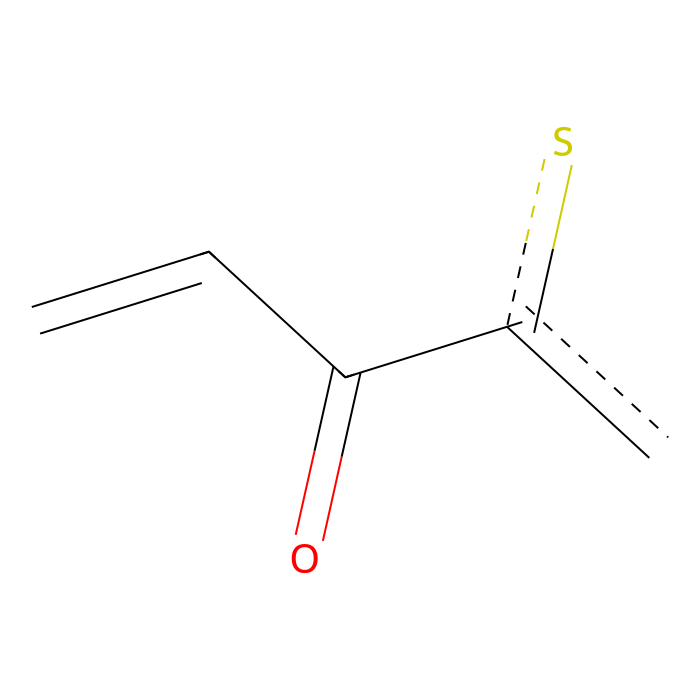

Analyzing molecule O=C(C=CC1=CC=CC=C1)C1=CC2=C(O1)C=CC=C2 (index 20) for bit 1667:
Saved substructure SVG: substructure_molecule_20_idx_0.svg


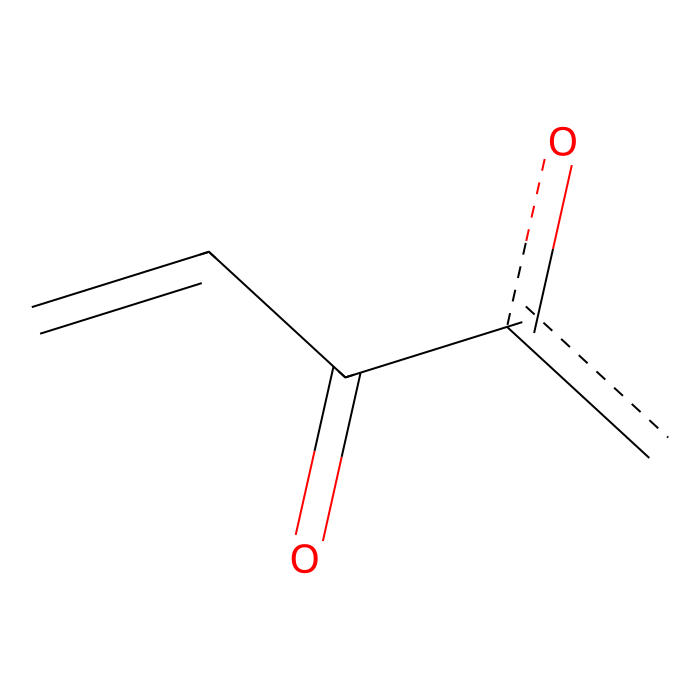

Analyzing molecule O=C(C=CC1=CC=CC=C1)C1=CC2=C(S1)C=CC=C2 (index 21) for bit 1667:
Saved substructure SVG: substructure_molecule_21_idx_0.svg


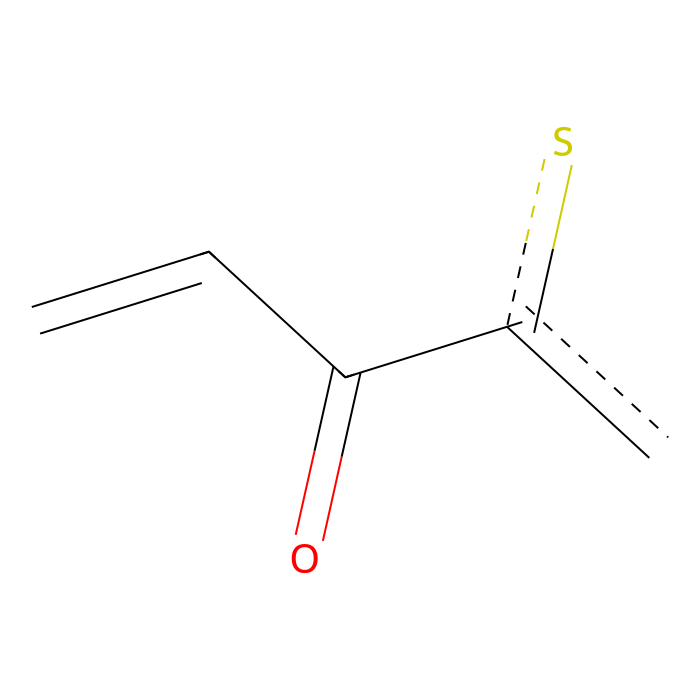

Analyzing molecule O=C(C=CC1=CC=C(C=C1)C#N)C1=CC=CC=C1 (index 22) for bit 1667:
Saved substructure SVG: substructure_molecule_22_idx_0.svg


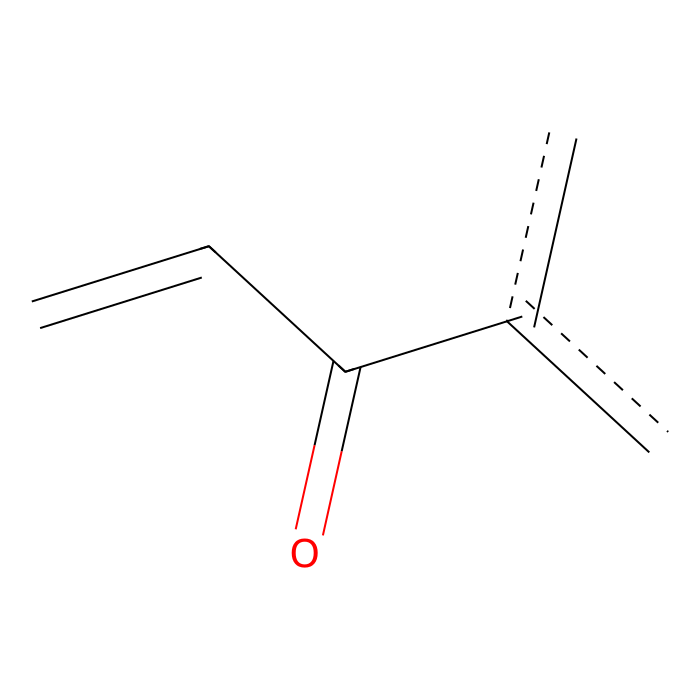

Analyzing molecule O=C(C=CC1=CC=CC=C1)C1=CC2=C(C=CC=C2)C=C1 (index 23) for bit 1667:
Saved substructure SVG: substructure_molecule_23_idx_0.svg


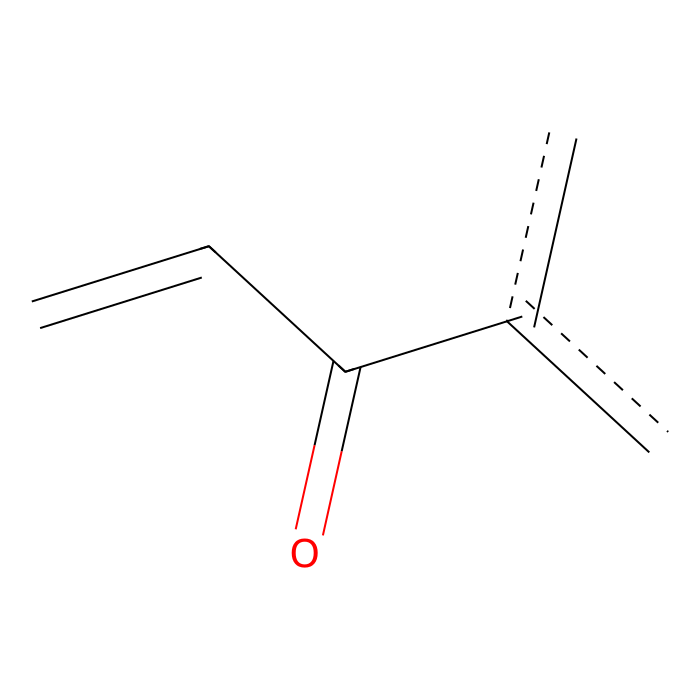

Analyzing molecule FC1=CC=C(C=C1)C(=O)C=CC1=CC=C(Cl)C=C1 (index 24) for bit 1667:
Saved substructure SVG: substructure_molecule_24_idx_0.svg


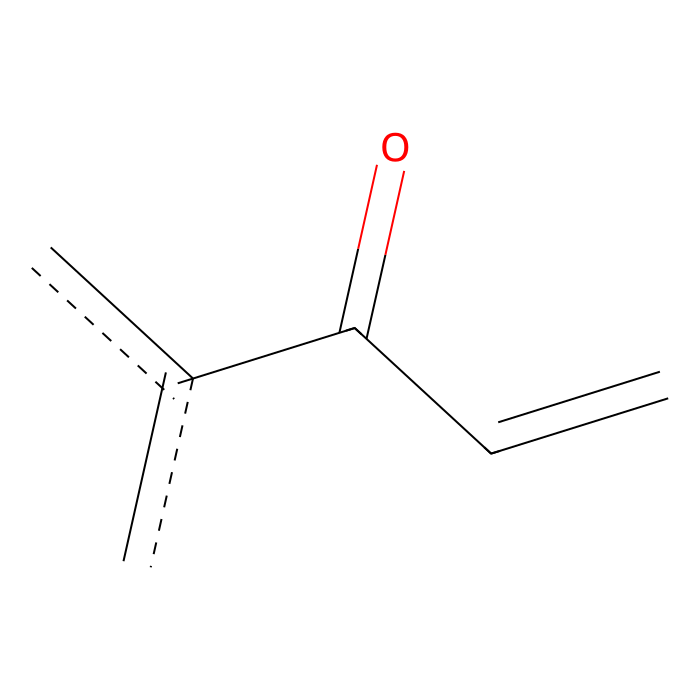

Analyzing molecule O=C(\C=C\C=C\C1=CC=CC=C1)C1=CC=CC=C1 (index 25) for bit 1667:
Saved substructure SVG: substructure_molecule_25_idx_0.svg


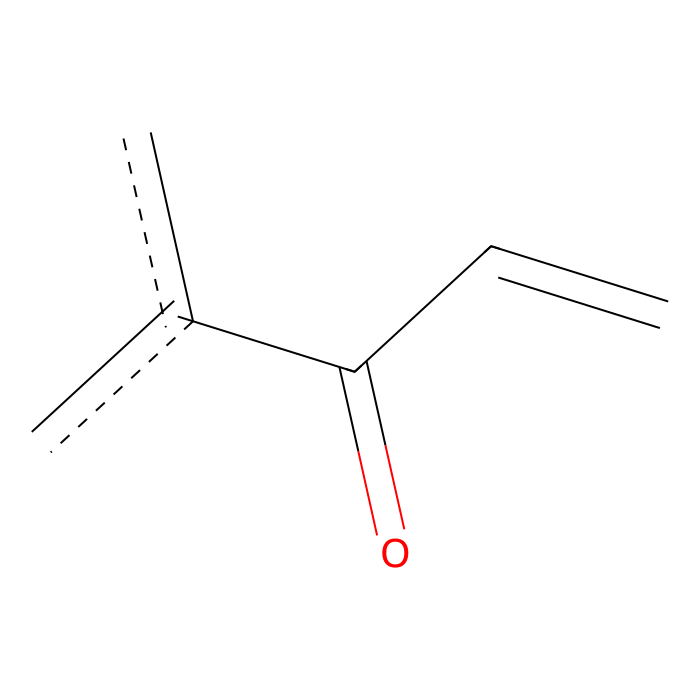

Analyzing molecule C\C=C\C=C\C(=O)C1=CC=CC=C1 (index 26) for bit 1667:
Saved substructure SVG: substructure_molecule_26_idx_0.svg


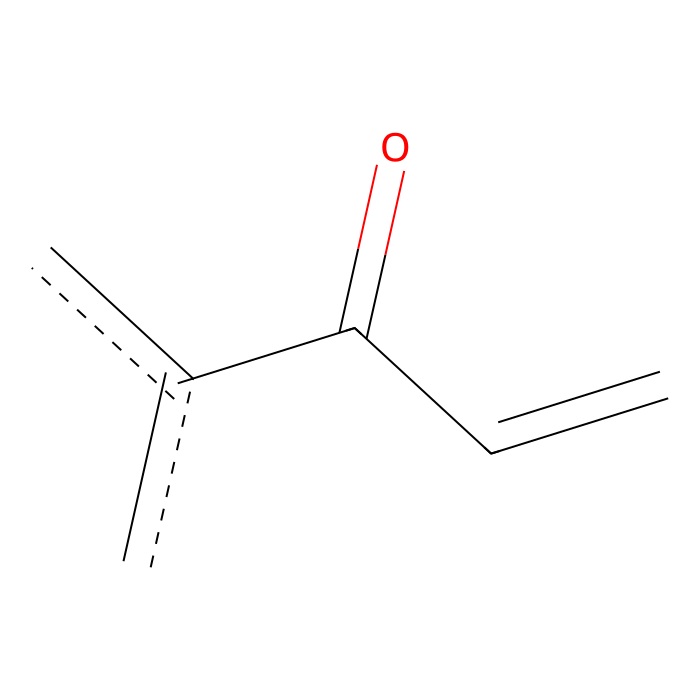

Analyzing molecule CC1=CC=CC=C1C(=O)C=CC1=CC=CC=C1 (index 27) for bit 1667:
Saved substructure SVG: substructure_molecule_27_idx_0.svg


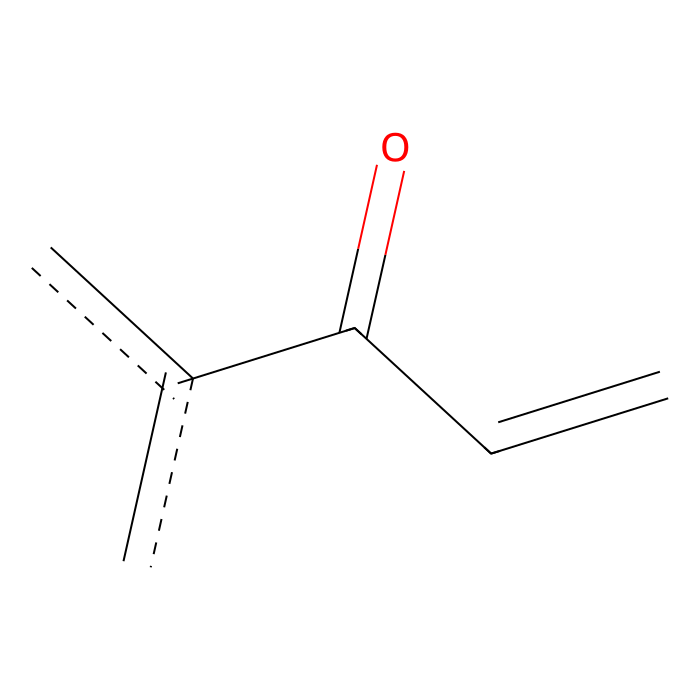

Analyzing molecule FC(F)(C1=CC=C(C=C1)C=CC(C2=CC=CC=C2)=O)F (index 28) for bit 1667:
Saved substructure SVG: substructure_molecule_28_idx_0.svg


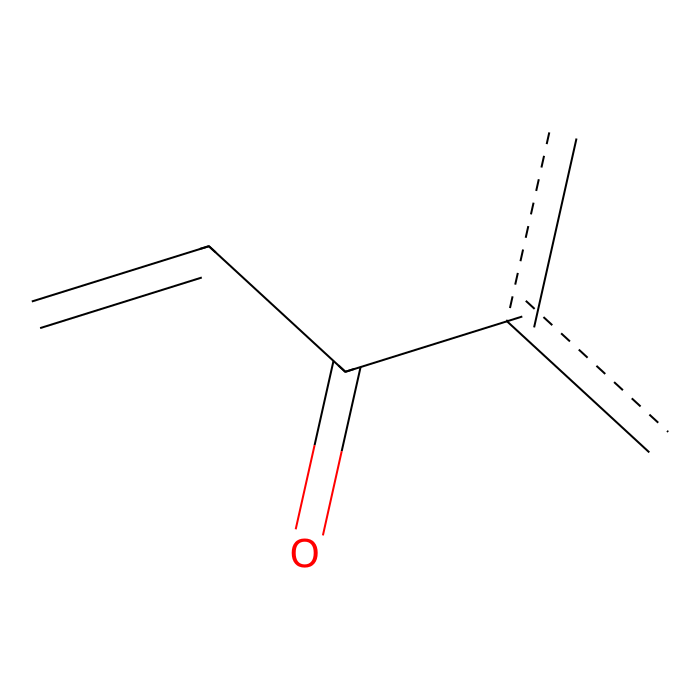

Analyzing molecule FC1=CC=C(C=CC(=O)C2=CC=C(C=C2)N(=O)=O)C=C1 (index 29) for bit 1667:
Saved substructure SVG: substructure_molecule_29_idx_0.svg


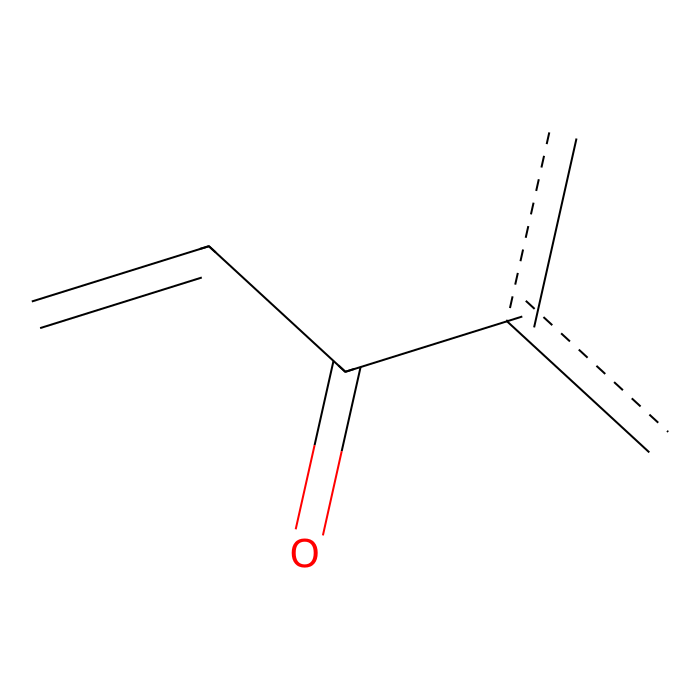

Analyzing molecule COC1=CC(C=CC(C2=CC=CC=C2)=O)=CC=C1 (index 30) for bit 1667:
Saved substructure SVG: substructure_molecule_30_idx_0.svg


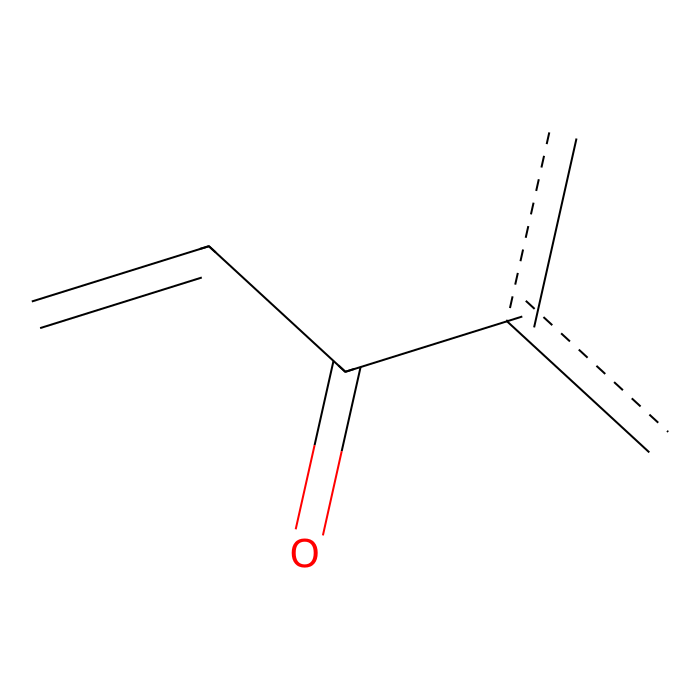

Analyzing molecule CN1C=CC=C1C(=O)C=CC1=CC=CC=C1 (index 31) for bit 1667:
Saved substructure SVG: substructure_molecule_31_idx_0.svg


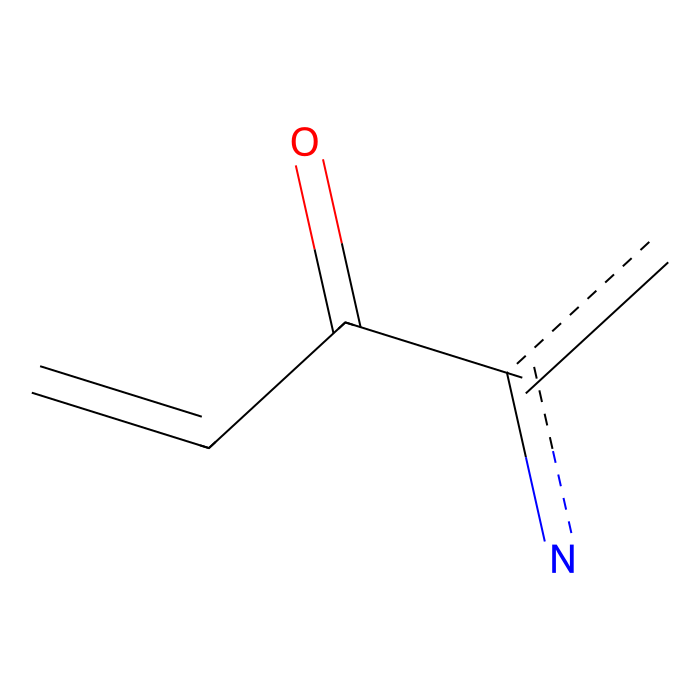

Analyzing molecule O=C(C1=CC=CC2=C1C=CC=C2)C=CC3=CC=CC=C3 (index 32) for bit 1667:
Saved substructure SVG: substructure_molecule_32_idx_0.svg


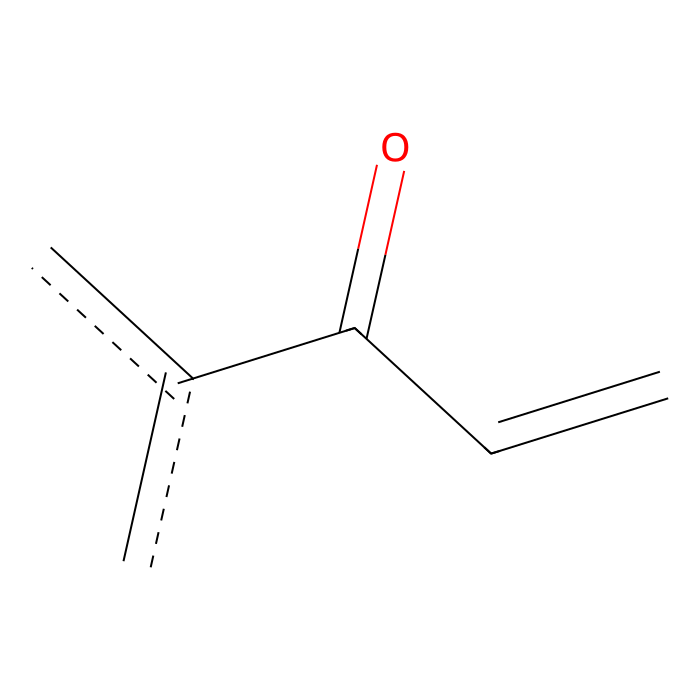

Analyzing molecule O=C(C1=CC=CC=C1)C=C2CCCC=C2 (index 33) for bit 1667:
Saved substructure SVG: substructure_molecule_33_idx_0.svg


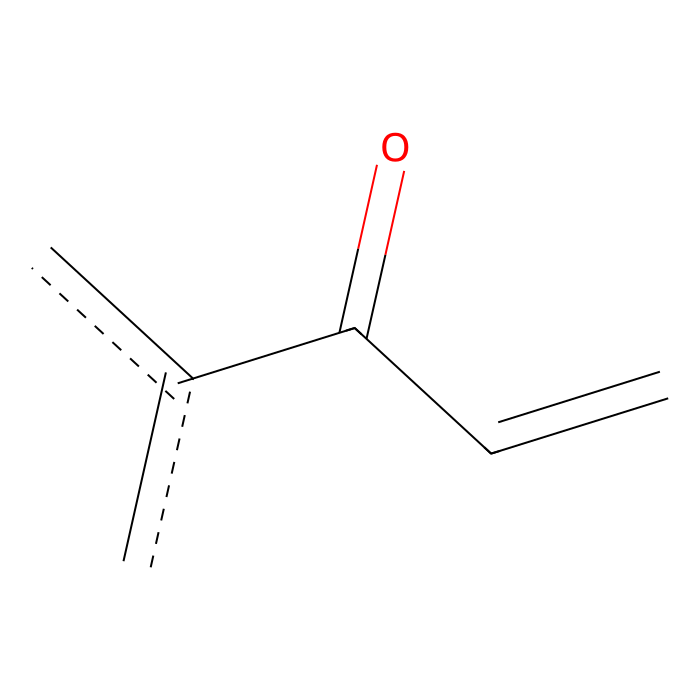

Analyzing molecule CC(C=CC(C1=CC=CC=C1)=O)C (index 34) for bit 1667:
Saved substructure SVG: substructure_molecule_34_idx_0.svg


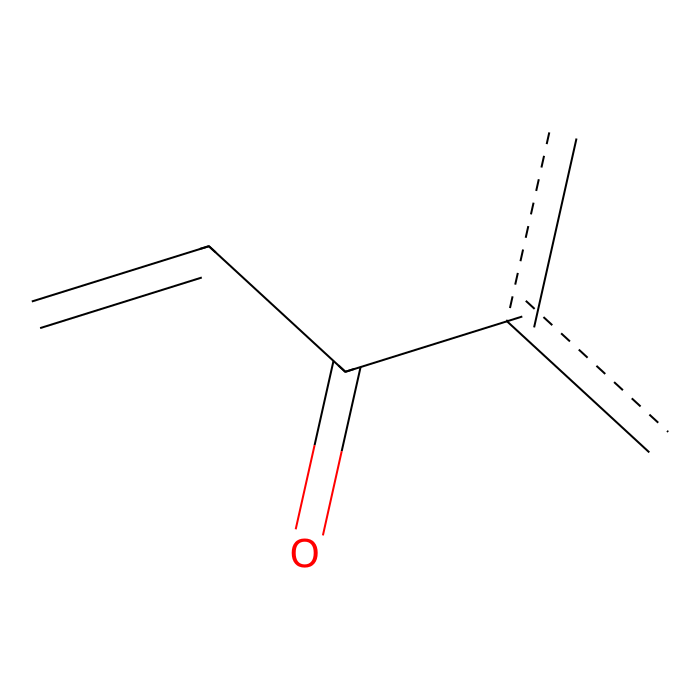

Analyzing molecule CC1=CC=C(C=C1)C=CC(C2=CC=C(N(=O)=O)C=C2)=O (index 35) for bit 1667:
Saved substructure SVG: substructure_molecule_35_idx_0.svg


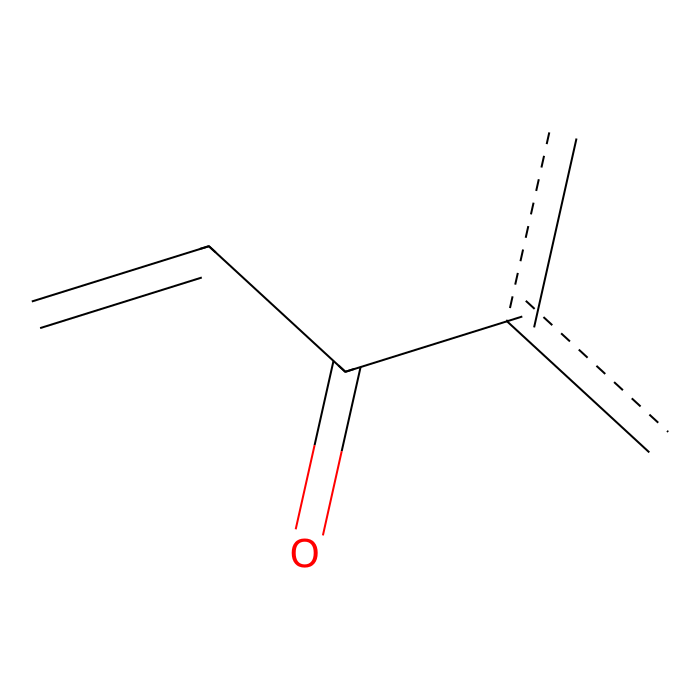

Analyzing molecule ClC1=CC=C(C=CC(C2=CC=C(C=C2)N(=O)=O)=O)C=C1 (index 36) for bit 1667:
Saved substructure SVG: substructure_molecule_36_idx_0.svg


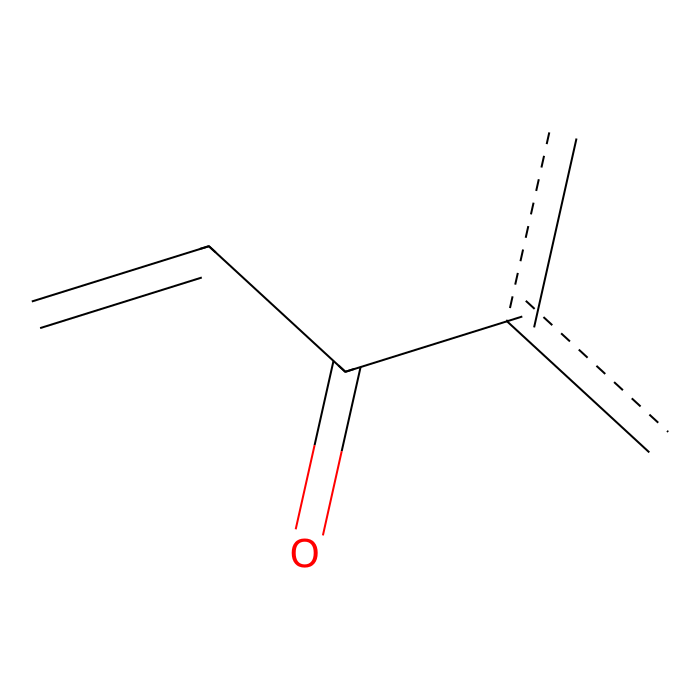

Analyzing molecule O=C(C1=CC=CC=C1)C=CC(C2=CC=CC=C2)=O (index 37) for bit 1667:
Saved substructure SVG: substructure_molecule_37_idx_0.svg


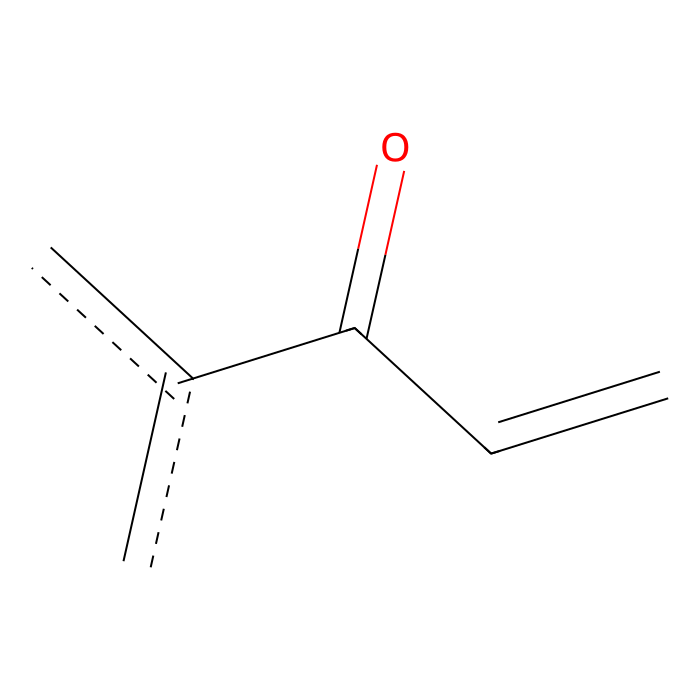

Saved substructure SVG: substructure_molecule_37_idx_1.svg


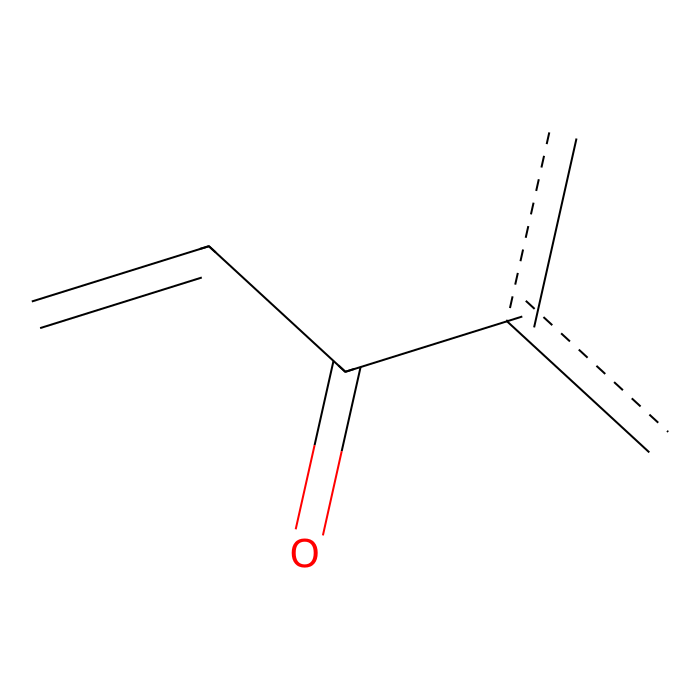

Skipping molecule CCCCCC=CC(C)=O (index 38) because bit 1667 is zero or NaN.
Skipping molecule O=C1C(C)=CCCC1 (index 39) because bit 1667 is zero or NaN.
Analyzing molecule O=C(/C=C/C1=CC=CC=C1C)C2=CC=CC=C2 (index 40) for bit 1667:
Saved substructure SVG: substructure_molecule_40_idx_0.svg


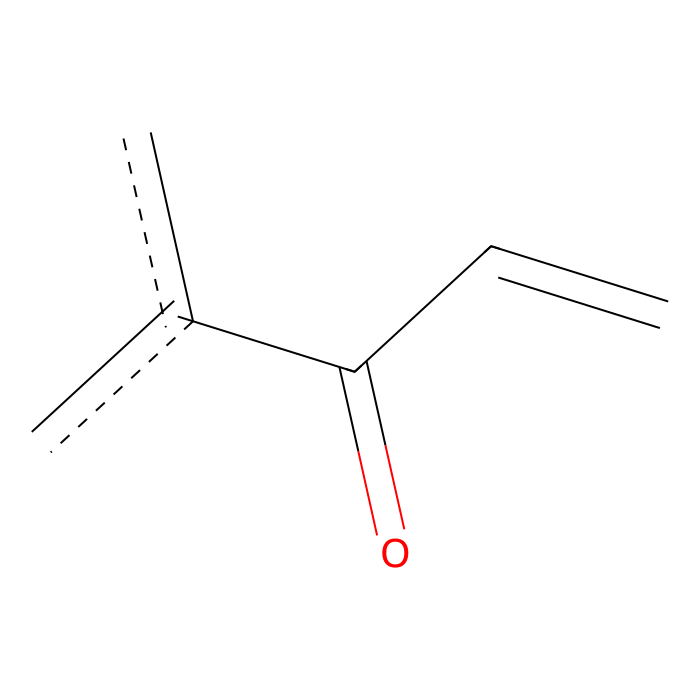

Analyzing molecule O=C(/C=C/C1=CC=CC=C1OC)C2=CC=CC=C2 (index 41) for bit 1667:
Saved substructure SVG: substructure_molecule_41_idx_0.svg


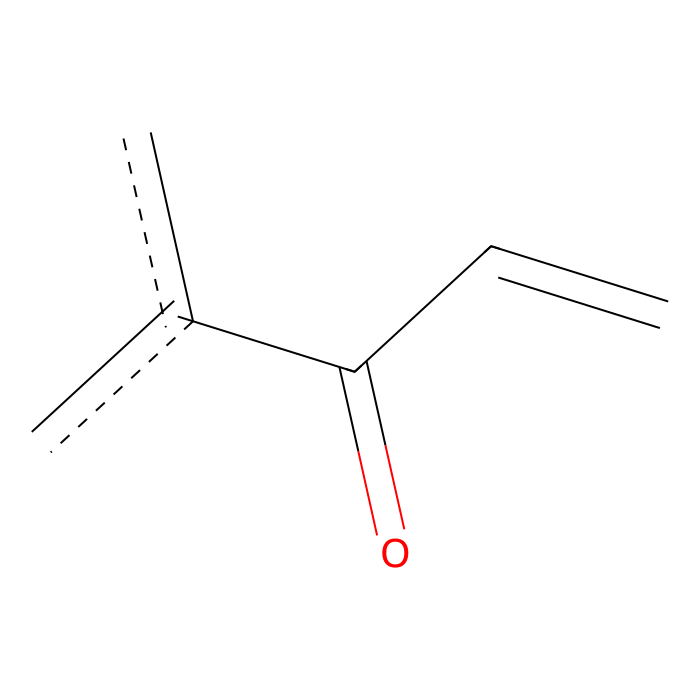

Analyzing molecule O=C(/C=C/C1=CC=C(OC)C=C1)C2=CC=CC=C2 (index 42) for bit 1667:
Saved substructure SVG: substructure_molecule_42_idx_0.svg


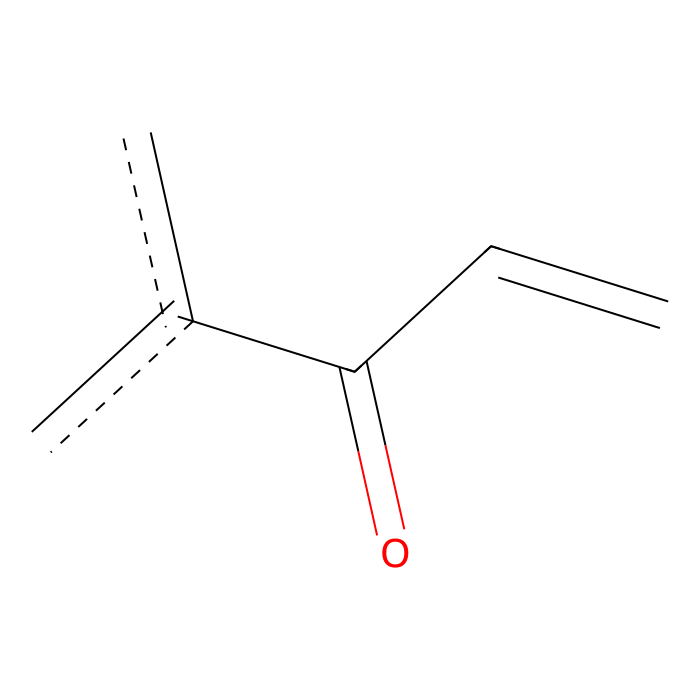

Analyzing molecule O=C(/C=C/C1=CC=CO1)C2=CC=CC=C2 (index 43) for bit 1667:
Saved substructure SVG: substructure_molecule_43_idx_0.svg


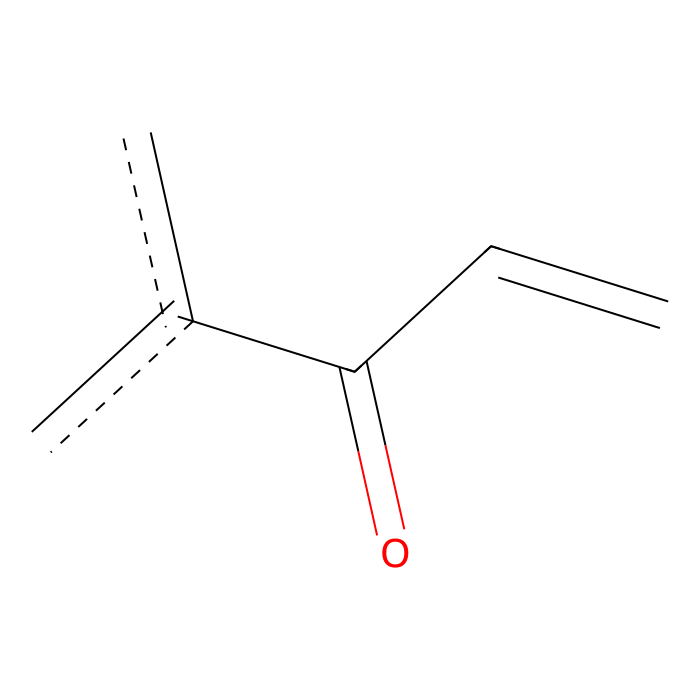

Analyzing molecule O=C(/C=C/C1=CC=CN1)C2=CC=CC=C2 (index 44) for bit 1667:
Saved substructure SVG: substructure_molecule_44_idx_0.svg


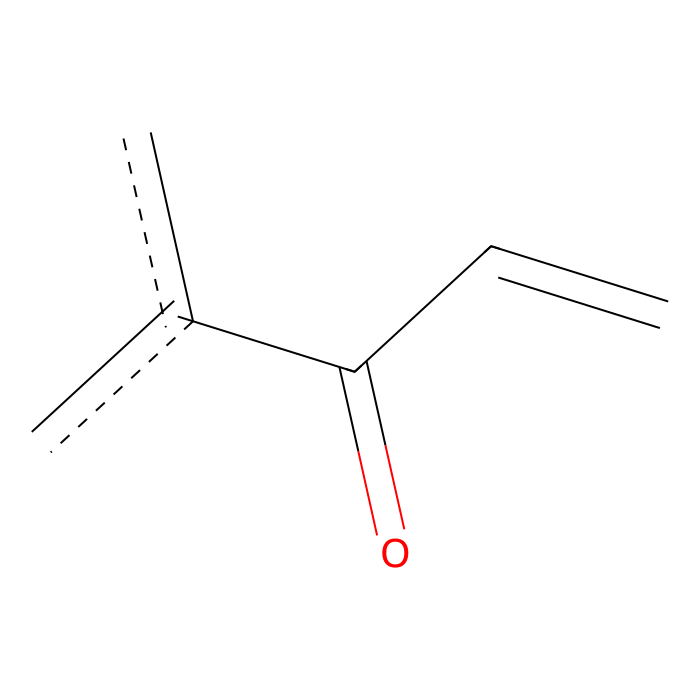

Analyzing molecule O=C(/C=C/C1=CC=CS1)C2=CC=CC=C2 (index 45) for bit 1667:
Saved substructure SVG: substructure_molecule_45_idx_0.svg


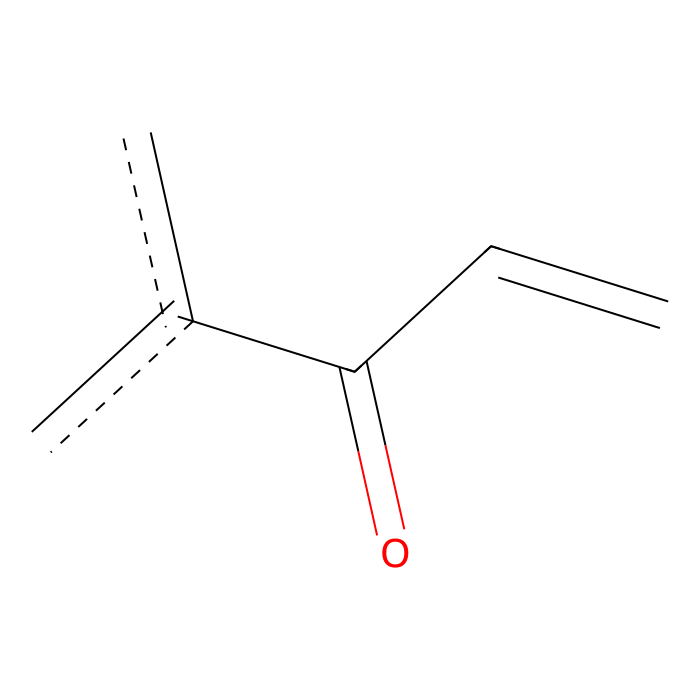

Analyzing molecule O=C(/C=C1CCCCCC/1)C2=CC=CC=C2 (index 46) for bit 1667:
Saved substructure SVG: substructure_molecule_46_idx_0.svg


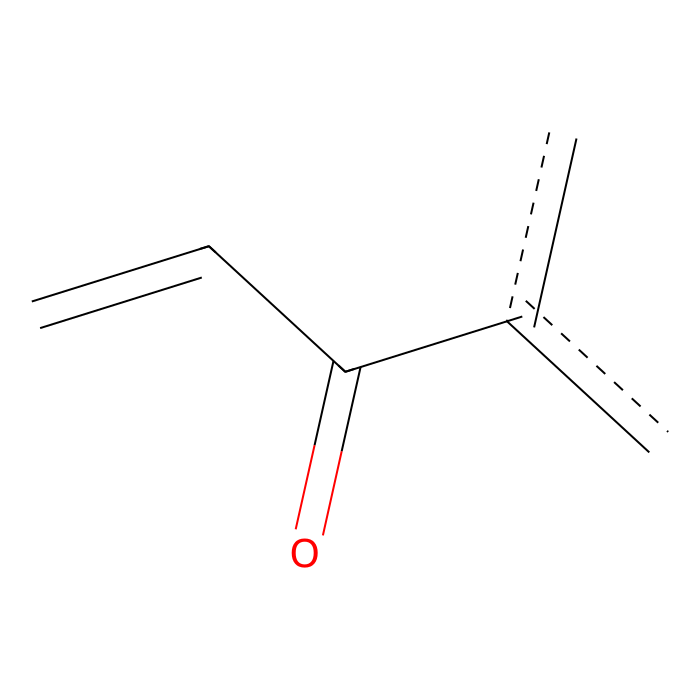

Skipping molecule CCCCCCC(/C=C/C1=CC=CC=C1)=O (index 47) because bit 1667 is zero or NaN.
Skipping molecule O=C1CCC(C2=CC=CC=C2)=C1 (index 48) because bit 1667 is zero or NaN.
Analyzing molecule CC1=CC=C(C(/C=C/C2=C(C)C=C(C)C=C2C)=O)C=C1 (index 49) for bit 1667:
Saved substructure SVG: substructure_molecule_49_idx_0.svg


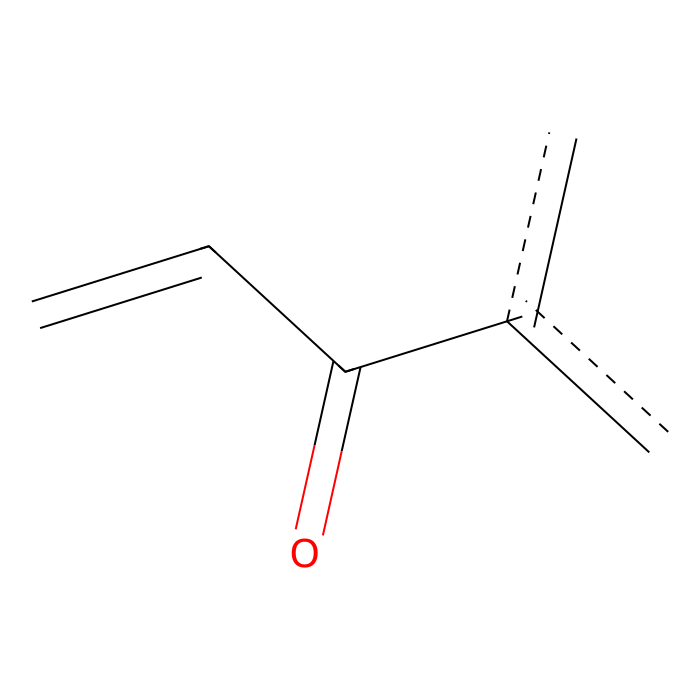

Analyzing molecule O=C(/C=C/C1=C(C)C=C(C)C=C1C)C2=CC=C([N+]([O-])=O)C=C2 (index 50) for bit 1667:
Saved substructure SVG: substructure_molecule_50_idx_0.svg


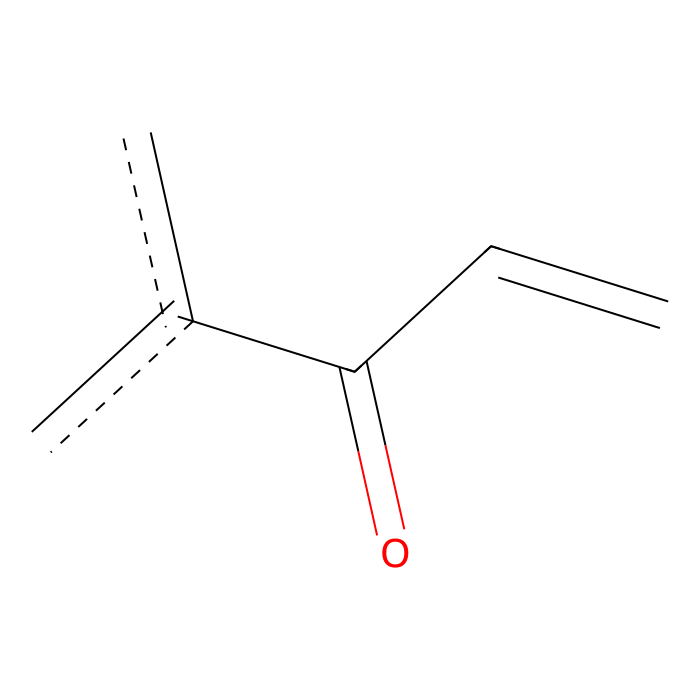

Skipping molecule O=C(CCCC/1=O)C1=C\C2=CC=CC=C2 (index 51) because bit 1667 is zero or NaN.
Skipping molecule O=C(C=CC/1=O)C1=C/C2=CC=CC=C2 (index 52) because bit 1667 is zero or NaN.
Skipping molecule O=S(/C=C/C1=CC=CC=C1)(C2=CC=CC=C2)=O (index 53) because bit 1667 is zero or NaN.
Skipping molecule O=[N+](/C=C/C1=CC=CC=C1)[O-] (index 54) because bit 1667 is zero or NaN.
Skipping molecule O=C(C1=CC=CC=C1)C/C=C/C2=CC=CC=C2 (index 55) because bit 1667 is zero or NaN.
Skipping molecule OC/C=C/C1=CC=CC=C1 (index 56) because bit 1667 is zero or NaN.
Analyzing molecule O=C(/C=C/C1=CC=C(OC2=CC=CC=C2)C=C1)C3=CC=CC=C3 (index 57) for bit 1667:
Saved substructure SVG: substructure_molecule_57_idx_0.svg


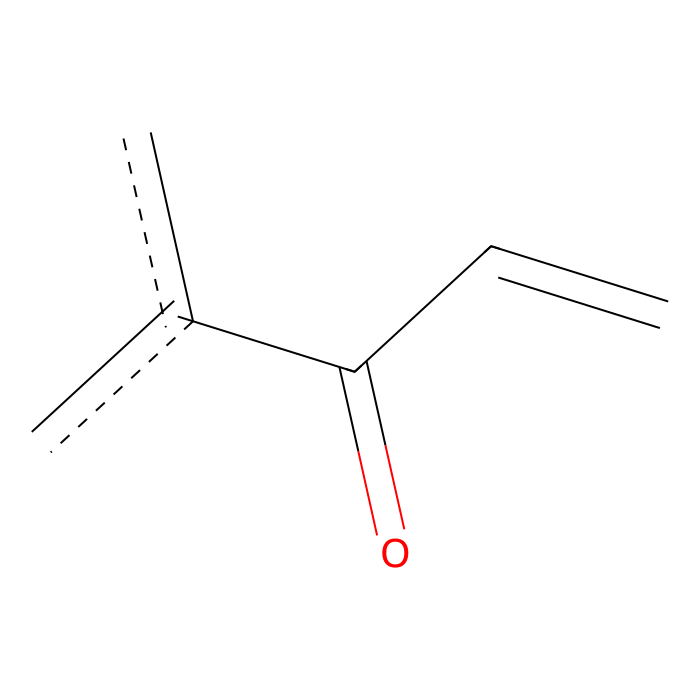

Analyzing molecule O=C(/C=C/C1=CC=C(CC(C)C)C=C1)C2=CC=CC=C2 (index 58) for bit 1667:
Saved substructure SVG: substructure_molecule_58_idx_0.svg


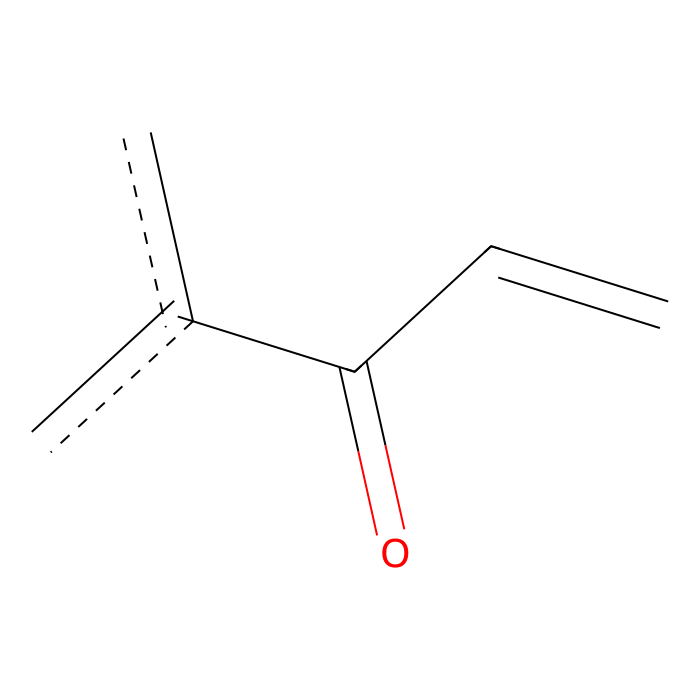

Analyzing molecule O=C(/C=C/C1=CC=C(C=C(OC)C=C2)C2=C1)C3=CC=CC=C3 (index 59) for bit 1667:
Saved substructure SVG: substructure_molecule_59_idx_0.svg


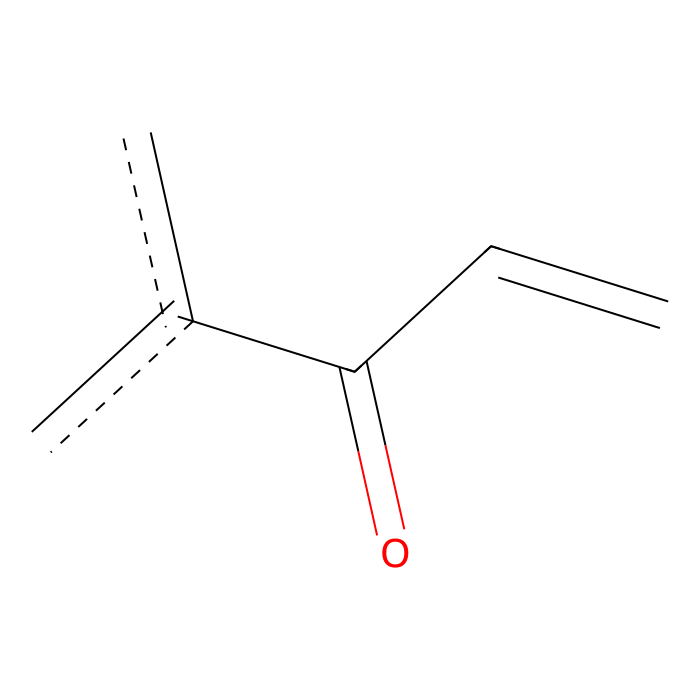

Skipping molecule O=C(/C=C/C1=CC=CC=C1)C(C)(C)C (index 60) because bit 1667 is zero or NaN.
Skipping molecule O=C(/C=C/C1=CC=C(OC)C=C1)C(C)(C)C (index 61) because bit 1667 is zero or NaN.
Skipping molecule O=C(/C=C/C1=CC=CC=C1)C2CCCCC2 (index 62) because bit 1667 is zero or NaN.
Skipping molecule O=C(/C=C/C1=CC=C(OC)C=C1)OCC (index 63) because bit 1667 is zero or NaN.
Skipping molecule O=C(/C=C/C1=CC=C(Br)C=C1)OCC (index 64) because bit 1667 is zero or NaN.
Analyzing molecule O=C(/C=C/C1=CC=CC=C1)C2=CC=CN=C2 (index 65) for bit 1667:
Saved substructure SVG: substructure_molecule_65_idx_0.svg


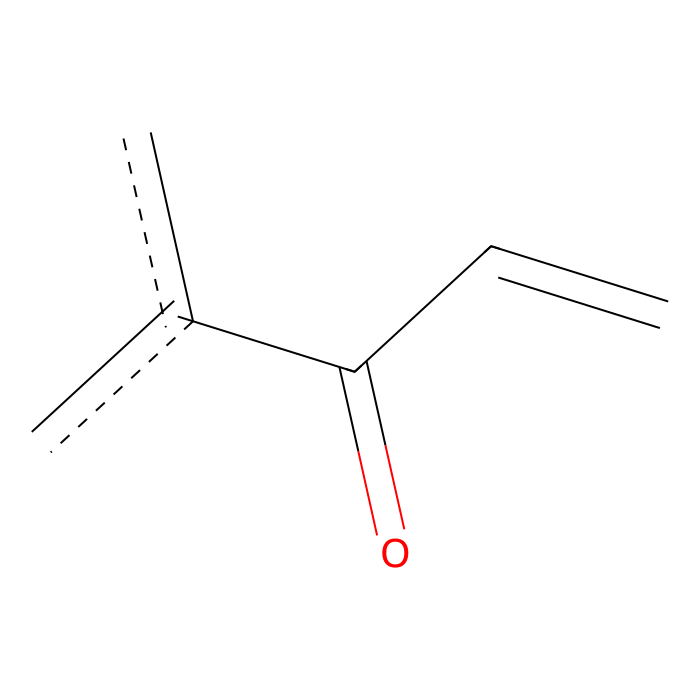

Skipping molecule CC(C1=CC[C@]2([H])[C@]1(C)CC[C@@]3([H])[C@@]2([H])CC=C4[C@]3(C)CC[C@H](OC(C)=O)C4)=O (index 66) because bit 1667 is zero or NaN.
Analysis complete.


In [13]:
df_ = pd.read_excel('../Data/QSPR_epoxidation_classifier.xlsx')
# Generate Morgan Fingerprints
counts_df, mol_objs = generate_morgan_fingerprints(df_['SMILES'])

# Specify the bit index you want to analyze
bit_index_to_analyze = 1667

# Iterate through molecules, skipping if the bit is zero and handling potential errors.
for i in range(len(df_['SMILES'])):
    smiles = df_['SMILES'][i]
    mol = mol_objs[i]
    bit_value = counts_df.loc[i, f'C_FP_{bit_index_to_analyze}']

    if pd.isna(bit_value) or bit_value == 0:
        print(f"Skipping molecule {smiles} (index {i}) because bit {bit_index_to_analyze} is zero or NaN.")
        continue

    print(f"Analyzing molecule {smiles} (index {i}) for bit {bit_index_to_analyze}:")
    try:
        substructures = analyze_fingerprint_bit(mol, bit_index_to_analyze, fingerprint_radius=2, depiction_radius=2)
        if not substructures:
            print(f"No substructures found for molecule index {i}.")
            continue

        for idx, (atom_index, radius, submol) in enumerate(substructures):
            filename = f"substructure_molecule_{i}_idx_{idx}.svg"
            save_substructure_as_svg(submol, filename)
            print(f"Saved substructure SVG: {filename}")

            # Optional: display SVG inline (only in Jupyter Notebook or IPython environment)
            display(SVG(filename=filename))

    except Exception as e:
        print(f"Error analyzing molecule {smiles} (index {i}): {e}")

print("Analysis complete.")